# 04. Regresión complementaria de días de estancia

En este notebook se explora una formulación complementaria del problema de larga estancia: la estimación aproximada del número de días que un perro permanece en el refugio.

A diferencia del notebook de modelización principal, cuyo objetivo era clasificar si un perro superaba o no el umbral de larga estancia, en este análisis se plantea un problema de regresión.

El objetivo no es sustituir el modelo principal de clasificación, sino evaluar si la predicción de días de estancia aporta información adicional sobre la severidad del riesgo y sobre la dificultad de anticipar con precisión la duración real de la estancia.

Este análisis permitirá comparar dos enfoques:

- clasificación de larga estancia, orientada a priorizar perros en riesgo;
- regresión de días de estancia, orientada a estimar la duración aproximada de la estancia.

La hipótesis de partida es que la clasificación puede resultar más robusta y útil operativamente que la predicción exacta de días, debido a la alta variabilidad de las estancias y a la presencia de valores extremos.

In [99]:
# Imports generales

from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

In [100]:
# Definición de rutas del proyecto

project_path = Path.cwd()

if project_path.name == "notebooks":
    project_path = project_path.parent

data_path = project_path / "data"
processed_data_path = data_path / "processed"

outputs_path = project_path / "outputs"
figures_path = outputs_path / "figures"
models_path = outputs_path / "models"
regression_path = outputs_path / "regression"

for path in [figures_path, models_path, regression_path]:
    path.mkdir(parents=True, exist_ok=True)

print("Ruta del proyecto:", project_path)
print("Ruta de datos procesados:", processed_data_path)
print("Ruta de modelos:", models_path)
print("Ruta de salidas de regresión:", regression_path)

Ruta del proyecto: g:\Mi unidad\TFM\invisible-dogs-tfm
Ruta de datos procesados: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed
Ruta de modelos: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models
Ruta de salidas de regresión: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\regression


In [101]:
# Carga del dataset preparado en la fase 01

dataset_path = processed_data_path / "invisible_dogs_dataset_preparado.csv"

dogs_model_ready = pd.read_csv(dataset_path)

for col in ["intake_datetime", "outcome_datetime"]:
    if col in dogs_model_ready.columns:
        dogs_model_ready[col] = pd.to_datetime(dogs_model_ready[col], errors="coerce")

print("Dataset preparado cargado correctamente.")
print("Ruta:", dataset_path)
print("Dimensiones:", dogs_model_ready.shape)

display(dogs_model_ready.head())

Dataset preparado cargado correctamente.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\invisible_dogs_dataset_preparado.csv
Dimensiones: (93803, 57)


,animal_id,intake_datetime,outcome_datetime,stay_days,stay_days_rounded,target_long_stay,intake_type,intake_condition,sex_upon_intake,sex,sterilized_intake,age_upon_intake,age_months_intake,age_group,name_intake,has_name_intake,found_location,found_location_grouped,breed_intake,is_mixed_breed,main_breed,main_breed_grouped,has_secondary_breed,secondary_breed,breed_num_terms,color_intake,main_color,main_color_grouped,has_secondary_color,secondary_color,color_num_terms,intake_month,intake_dayofweek,intake_hour,intake_is_weekend,intake_season,age_group_intake_type,condition_intake_type,breed_age_group,season_condition,previous_intake_count,is_repeat_intake,days_since_previous_intake,previous_outcome_type,previous_stay_days,previous_long_stay_count,previous_owner_surrender_count,previous_stray_count,n_intakes_dogs_last_7d,n_intakes_dogs_last_30d,n_outcomes_dogs_last_7d,n_outcomes_dogs_last_30d,n_adoptions_dogs_last_30d,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d,outcome_type,outcome_subtype
0,A006100,2014-03-07 14:26:00,2014-03-08 17:10:00,1.113889,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,6 years,72.0,Adulto,Scamp,Con nombre registrado,8700 Research in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,3,4,14,0,Primavera,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,171.0,864.0,163.0,772.0,337.0,460.0,1.117723,Return to Owner,NaN
1,A006100,2014-12-19 10:21:00,2014-12-20 16:35:00,1.259722,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,7 years,84.0,Adulto,Scamp,Con nombre registrado,8700 Research Blvd in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,12,4,10,0,Invierno,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Invierno | Normal,1,1,286.829861,Return to Owner,2.0,0.0,0.0,0.0,228.0,925.0,202.0,976.0,414.0,404.0,0.946776,Return to Owner,NaN
2,A047759,2014-04-02 15:55:00,2014-04-07 15:12:00,4.970139,5,0,Owner Surrender,Normal,Neutered Male,Macho,Esterilizado,10 years,120.0,Senior,Oreo,Con nombre registrado,Austin (TX),Austin,Dachshund,Raza no mixta,Dachshund,Dachshund,0,NaN,1,Tricolor,Tricolor,Tricolor,0,NaN,1,4,2,15,0,Primavera,Senior | Owner Surrender,Normal | Owner Surrender,Dachshund | Senior,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,205.0,900.0,191.0,864.0,354.0,463.0,1.040462,Transfer,Partner
3,A134067,2013-11-16 09:02:00,2013-11-16 11:54:00,0.119444,1,0,Public Assist,Injured,Neutered Male,Macho,Esterilizado,16 years,192.0,Senior,Bandit,Con nombre registrado,12034 Research Blvd in Austin (TX),Austin,Shetland Sheepdog,Raza no mixta,Shetland Sheepdog,Otras razas,0,NaN,1,Brown/White,Brown,Brown,1,White,2,11,5,9,1,Otoño,Senior | Public Assist,Injured | Public Assist,Otras razas | Senior,Otoño | Injured,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,181.0,855.0,176.0,777.0,288.0,314.0,1.098972,Return to Owner,NaN
4,A141142,2013-11-16 14:46:00,2013-11-17 11:40:00,0.870833,1,0,Stray,Aged,Spayed Female,Hembra,Esterilizado,15 years,180.0,Senior,Bettie,Con nombre registrado,Austin (TX),Austin,Labrador Retriever/Pit Bull,Raza mixta,Labrador Retriever,Labrador Retriever,1,Pit Bull,2,Black/White,Black,Black,1,White,2,11,5,14,1,Otoño,Senior | Stray,Aged | Stray,Labrador Retriever | Senior,Otoño | Aged,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,179.0,854.0,174.0,786.0,290.0,315.0,1.085133,Return to Owner,NaN


In [102]:
# Carga del objeto del modelo final de clasificación

modelo_final_path = models_path / "modelo_final_invisible_dogs.pkl"

modelo_final_guardado = joblib.load(modelo_final_path)

modelo_final_nombre = modelo_final_guardado.get("modelo_final_nombre")
variables_catboost_clasificacion = modelo_final_guardado.get("variables_catboost", [])
variables_lgbm_clasificacion = modelo_final_guardado.get("variables_lgbm", [])
variables_categoricas_catboost = modelo_final_guardado.get("variables_categoricas_catboost", [])

print("Modelo final de clasificación cargado correctamente.")
print("Modelo final:", modelo_final_nombre)
print("Variables CatBoost clasificación:", len(variables_catboost_clasificacion))
print("Variables LightGBM clasificación:", len(variables_lgbm_clasificacion))
print("Variables categóricas CatBoost:", len(variables_categoricas_catboost))

Modelo final de clasificación cargado correctamente.
Modelo final: Ensemble CatBoost + LightGBM
Variables CatBoost clasificación: 41
Variables LightGBM clasificación: 37
Variables categóricas CatBoost: 18


In [103]:
# Carga del split de test guardado en la fase de modelización

split_test_path = models_path / "split_test_modelizacion.csv"

dogs_regresion = dogs_model_ready.copy()

if split_test_path.exists():
    split_test_df = pd.read_csv(split_test_path)
    
    test_idx = (
        split_test_df["indice_original"]
        .dropna()
        .astype(int)
        .values
    )
    
    dogs_regresion["conjunto_evaluacion"] = "train_desarrollo"
    dogs_regresion.loc[test_idx, "conjunto_evaluacion"] = "test"
    
    print("Split de test cargado desde archivo guardado.")
    print("Ruta:", split_test_path)

else:
    print("No se ha encontrado split guardado. Se reconstruye con GroupShuffleSplit.")
    
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    
    indices = np.arange(len(dogs_regresion))
    
    train_idx, test_idx = next(
        gss.split(
            dogs_regresion,
            dogs_regresion["target_long_stay"],
            groups=dogs_regresion["animal_id"]
        )
    )
    
    dogs_regresion["conjunto_evaluacion"] = "train_desarrollo"
    dogs_regresion.loc[test_idx, "conjunto_evaluacion"] = "test"

dogs_regresion_train = dogs_regresion.loc[
    dogs_regresion["conjunto_evaluacion"] == "train_desarrollo"
].copy()

dogs_regresion_test = dogs_regresion.loc[
    dogs_regresion["conjunto_evaluacion"] == "test"
].copy()

animal_ids_train = set(dogs_regresion_train["animal_id"])
animal_ids_test = set(dogs_regresion_test["animal_id"])
animal_ids_solapados = animal_ids_train.intersection(animal_ids_test)

print("\nResumen del split utilizado:")
print("Registros totales:", len(dogs_regresion))
print("Registros en train/desarrollo:", len(dogs_regresion_train))
print("Registros en test:", len(dogs_regresion_test))
print("Perros únicos en train/desarrollo:", dogs_regresion_train["animal_id"].nunique())
print("Perros únicos en test:", dogs_regresion_test["animal_id"].nunique())
print("Perros repetidos entre train/desarrollo y test:", len(animal_ids_solapados))

Split de test cargado desde archivo guardado.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\split_test_modelizacion.csv

Resumen del split utilizado:
Registros totales: 93803
Registros en train/desarrollo: 75051
Registros en test: 18752
Perros únicos en train/desarrollo: 63644
Perros únicos en test: 15911
Perros repetidos entre train/desarrollo y test: 0


In [104]:
# Definición de la variable objetivo de regresión

variable_objetivo_regresion = "stay_days_rounded"

if variable_objetivo_regresion not in dogs_regresion.columns:
    variable_objetivo_regresion = "stay_days"

dogs_regresion[variable_objetivo_regresion] = pd.to_numeric(
    dogs_regresion[variable_objetivo_regresion],
    errors="coerce"
)

registros_iniciales = len(dogs_regresion)

dogs_regresion = dogs_regresion.loc[
    dogs_regresion[variable_objetivo_regresion].notna()
    & (dogs_regresion[variable_objetivo_regresion] >= 0)
].copy()

dogs_regresion["log1p_stay_days"] = np.log1p(
    dogs_regresion[variable_objetivo_regresion]
)

dogs_regresion_train = dogs_regresion.loc[
    dogs_regresion["conjunto_evaluacion"] == "train_desarrollo"
].copy()

dogs_regresion_test = dogs_regresion.loc[
    dogs_regresion["conjunto_evaluacion"] == "test"
].copy()

print("Variable objetivo de regresión:", variable_objetivo_regresion)
print("Registros iniciales:", registros_iniciales)
print("Registros válidos para regresión:", len(dogs_regresion))
print("Registros descartados:", registros_iniciales - len(dogs_regresion))

display(
    dogs_regresion[[variable_objetivo_regresion, "log1p_stay_days"]]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

Variable objetivo de regresión: stay_days_rounded
Registros iniciales: 93803
Registros válidos para regresión: 93803
Registros descartados: 0


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
stay_days_rounded,93803.0,21.630129,53.671792,0.0,1.000000,1.000000,1.000000,3.000000,6.00000,16.000000,51.000000,88.000000,256.980000,1913.000000
log1p_stay_days,93803.0,2.232125,1.165612,0.0,0.693147,0.693147,0.693147,1.386294,1.94591,2.833213,3.951244,4.488636,5.552882,7.556951


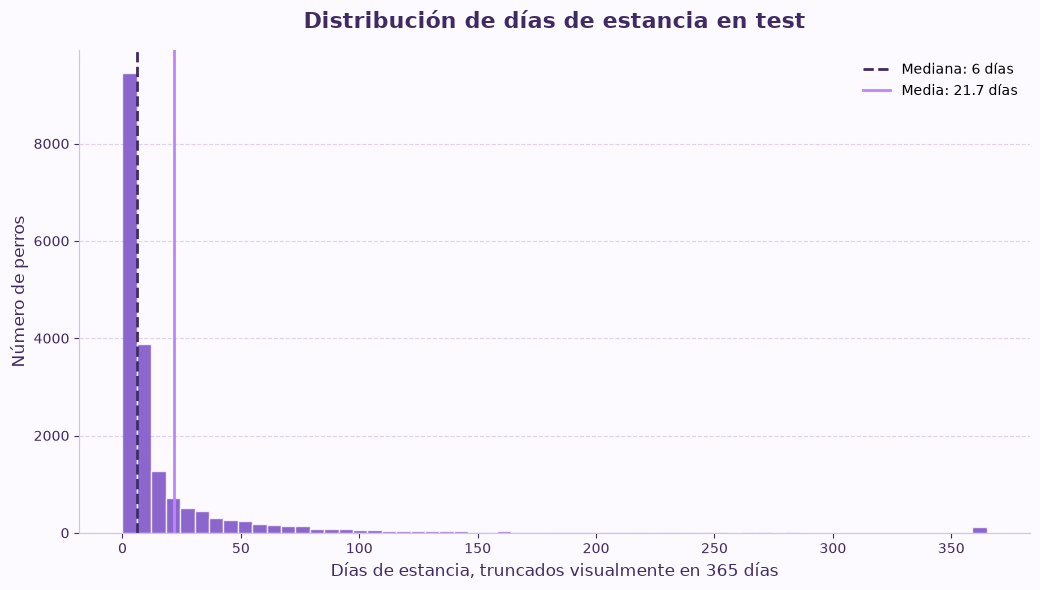

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\distribucion_dias_estancia_test_regresion.png


In [105]:
# Distribución de los días de estancia en el conjunto de test

datos_test_estancia = dogs_regresion_test[variable_objetivo_regresion].copy()

limite_visual = 365

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.hist(
    datos_test_estancia.clip(upper=limite_visual),
    bins=60,
    color="#6F42C1",
    alpha=0.80,
    edgecolor="white"
)

ax.axvline(
    datos_test_estancia.median(),
    color="#3F2A64",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {datos_test_estancia.median():.0f} días"
)

ax.axvline(
    datos_test_estancia.mean(),
    color="#C084FC",
    linestyle="-",
    linewidth=2,
    label=f"Media: {datos_test_estancia.mean():.1f} días"
)

ax.set_title(
    "Distribución de días de estancia en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    f"Días de estancia, truncados visualmente en {limite_visual} días",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Número de perros",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "distribucion_dias_estancia_test_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

La distribución de los días de estancia muestra una variable objetivo claramente asimétrica, con una concentración importante de estancias cortas y una cola larga de casos con estancias muy prolongadas.

Esta forma de la distribución anticipa que la regresión será un problema más complejo que la clasificación binaria de larga estancia. Mientras que la clasificación solo necesita separar los casos que superan un umbral operativo, la regresión intenta aproximar una duración concreta, lo que resulta más sensible a valores extremos y trayectorias atípicas.

Por este motivo, en las siguientes secciones se explorará la predicción de la estancia utilizando tanto la escala original de días como una transformación logarítmica mediante `log1p(stay_days)`.

## 2. Preparación de variables para la regresión

Para mantener la coherencia con el modelo principal de clasificación, se reutilizan las variables predictoras empleadas en la fase de modelización.

No se utilizan variables relacionadas con la salida final del animal ni variables derivadas directamente de la duración de la estancia, ya que introducirían fuga de información.

El objetivo de esta sección es construir una matriz de variables explicativas adecuada para entrenar modelos de regresión, manteniendo el mismo split de train/desarrollo y test utilizado en los notebooks anteriores.

In [106]:
# Selección de variables predictoras para la regresión

columnas_prohibidas_regresion = [
    "stay_days",
    "stay_days_rounded",
    "log1p_stay_days",
    "target_long_stay",
    "outcome_datetime",
    "outcome_type",
    "outcome_subtype",
    "conjunto_evaluacion"
]

variables_regresion_base = sorted(
    set(variables_catboost_clasificacion)
    .union(set(variables_lgbm_clasificacion))
)

variables_regresion_base = [
    col for col in variables_regresion_base
    if col in dogs_regresion.columns
    and col not in columnas_prohibidas_regresion
]

variables_catboost_regresion = [
    col for col in variables_catboost_clasificacion
    if col in variables_regresion_base
]

variables_lgbm_regresion = [
    col for col in variables_lgbm_clasificacion
    if col in variables_regresion_base
]

variables_categoricas_catboost_regresion = [
    col for col in variables_categoricas_catboost
    if col in variables_catboost_regresion
]

print("Variables disponibles para regresión:", len(variables_regresion_base))
print("Variables CatBoost regresión:", len(variables_catboost_regresion))
print("Variables LightGBM regresión:", len(variables_lgbm_regresion))
print("Variables categóricas CatBoost regresión:", len(variables_categoricas_catboost_regresion))

print("\nVariables excluidas por seguridad:")
for col in columnas_prohibidas_regresion:
    if col in dogs_regresion.columns:
        print("-", col)

Variables disponibles para regresión: 44
Variables CatBoost regresión: 41
Variables LightGBM regresión: 37
Variables categóricas CatBoost regresión: 18

Variables excluidas por seguridad:
- stay_days
- stay_days_rounded
- log1p_stay_days
- target_long_stay
- outcome_datetime
- outcome_type
- outcome_subtype
- conjunto_evaluacion


In [107]:
# Preparación de matrices de entrenamiento y test

X_train_reg_base = dogs_regresion_train[variables_regresion_base].copy()
X_test_reg_base = dogs_regresion_test[variables_regresion_base].copy()

y_train_dias = dogs_regresion_train[variable_objetivo_regresion].astype(float)
y_test_dias = dogs_regresion_test[variable_objetivo_regresion].astype(float)

y_train_log = np.log1p(y_train_dias)
y_test_log = np.log1p(y_test_dias)

print("Dimensiones de X_train:", X_train_reg_base.shape)
print("Dimensiones de X_test:", X_test_reg_base.shape)
print("Registros y_train:", len(y_train_dias))
print("Registros y_test:", len(y_test_dias))

print("\nResumen del objetivo en train/desarrollo:")
display(y_train_dias.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nResumen del objetivo en test:")
display(y_test_dias.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Dimensiones de X_train: (75051, 44)
Dimensiones de X_test: (18752, 44)
Registros y_train: 75051
Registros y_test: 18752

Resumen del objetivo en train/desarrollo:


count    75051.000000
mean        21.619139
std         53.487140
min          0.000000
25%          3.000000
50%          7.000000
75%         16.000000
90%         52.000000
95%         88.000000
99%        252.000000
max       1913.000000
Name: stay_days_rounded, dtype: float64


Resumen del objetivo en test:


count    18752.000000
mean        21.674115
std         54.405970
min          0.000000
25%          3.000000
50%          6.000000
75%         15.000000
90%         50.000000
95%         88.000000
99%        268.000000
max       1171.000000
Name: stay_days_rounded, dtype: float64

In [108]:
# Funciones auxiliares para evaluar modelos de regresión

def calcular_metricas_regresion(y_true, y_pred, nombre_modelo):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    
    errores_abs = np.abs(y_true - y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    spearman = (
        pd.Series(y_true)
        .corr(pd.Series(y_pred), method="spearman")
    )
    
    return {
        "modelo": nombre_modelo,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "median_absolute_error": median_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "spearman_corr": spearman,
        "error_abs_medio": errores_abs.mean(),
        "error_abs_mediano": np.median(errores_abs),
        "pct_error_menor_7_dias": np.mean(errores_abs <= 7),
        "pct_error_menor_14_dias": np.mean(errores_abs <= 14),
        "pct_error_menor_30_dias": np.mean(errores_abs <= 30)
    }


def evaluar_predicciones_regresion(y_true, y_pred, nombre_modelo):
    metricas = calcular_metricas_regresion(
        y_true=y_true,
        y_pred=y_pred,
        nombre_modelo=nombre_modelo
    )
    
    return pd.DataFrame([metricas])

In [109]:
# Modelos baseline de regresión

from sklearn.dummy import DummyRegressor

X_dummy_train = np.zeros((len(y_train_dias), 1))
X_dummy_test = np.zeros((len(y_test_dias), 1))

modelos_baseline_regresion = {
    "Baseline media días": DummyRegressor(strategy="mean"),
    "Baseline mediana días": DummyRegressor(strategy="median")
}

resultados_baseline_regresion = []

predicciones_baseline = {}

for nombre_modelo, modelo in modelos_baseline_regresion.items():
    modelo.fit(X_dummy_train, y_train_dias)
    
    y_pred = modelo.predict(X_dummy_test)
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    
    predicciones_baseline[nombre_modelo] = y_pred
    
    resultados_baseline_regresion.append(
        calcular_metricas_regresion(
            y_true=y_test_dias,
            y_pred=y_pred,
            nombre_modelo=nombre_modelo
        )
    )

resultados_baseline_regresion_df = pd.DataFrame(resultados_baseline_regresion)

columnas_redondear_regresion = [
    "mae",
    "rmse",
    "median_absolute_error",
    "r2",
    "spearman_corr",
    "error_abs_medio",
    "error_abs_mediano",
    "pct_error_menor_7_dias",
    "pct_error_menor_14_dias",
    "pct_error_menor_30_dias"
]

resultados_baseline_regresion_df[columnas_redondear_regresion] = (
    resultados_baseline_regresion_df[columnas_redondear_regresion]
    .round(4)
)

print("Resultados de modelos baseline de regresión sobre test:")
display(resultados_baseline_regresion_df)

Resultados de modelos baseline de regresión sobre test:


,modelo,mae,rmse,median_absolute_error,r2,spearman_corr,error_abs_medio,error_abs_mediano,pct_error_menor_7_dias,pct_error_menor_14_dias,pct_error_menor_30_dias
0,Baseline media días,24.7209,54.4045,16.6191,-0.0000,NaN,24.7209,16.6191,0.0961,0.3055,0.9029
1,Baseline mediana días,18.4437,56.3487,5.0000,-0.0728,NaN,18.4437,5.0000,0.7394,0.7987,0.8706


Los modelos baseline permiten establecer una referencia mínima para evaluar los modelos de regresión posteriores.

En un problema con una distribución tan asimétrica de días de estancia, la media y la mediana pueden comportarse de forma muy diferente. La media se ve afectada por estancias extremas, mientras que la mediana representa mejor el comportamiento típico de la mayoría de los perros.

Los modelos de regresión posteriores deberán mejorar estas referencias, especialmente en métricas robustas como el MAE, el error absoluto mediano y la correlación de Spearman.

## 3. Modelos de regresión sobre días de estancia

Una vez definidos los modelos baseline, se entrenan modelos supervisados de regresión para evaluar si las variables disponibles permiten estimar de forma aproximada la duración de la estancia.

Dado que la variable objetivo presenta una distribución muy asimétrica y una cola larga de valores extremos, se entrena el modelo sobre la transformación `log1p(stay_days)`. Posteriormente, las predicciones se transforman de nuevo a días mediante `expm1`.

Este enfoque reduce el efecto de las estancias extremadamente largas durante el entrenamiento y permite centrar el aprendizaje en patrones más generales de duración de la estancia.

In [110]:
# Split interno de train/desarrollo para ajustar modelos de regresión

gss_regresion = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

indices_train_desarrollo = np.arange(len(dogs_regresion_train))

idx_fit_regresion, idx_val_regresion = next(
    gss_regresion.split(
        dogs_regresion_train,
        dogs_regresion_train[variable_objetivo_regresion],
        groups=dogs_regresion_train["animal_id"]
    )
)

dogs_regresion_fit = dogs_regresion_train.iloc[idx_fit_regresion].copy()
dogs_regresion_val = dogs_regresion_train.iloc[idx_val_regresion].copy()

animal_ids_fit = set(dogs_regresion_fit["animal_id"])
animal_ids_val = set(dogs_regresion_val["animal_id"])

print("Split interno de regresión creado correctamente.")
print("Registros fit:", len(dogs_regresion_fit))
print("Registros validación:", len(dogs_regresion_val))
print("Perros únicos fit:", dogs_regresion_fit["animal_id"].nunique())
print("Perros únicos validación:", dogs_regresion_val["animal_id"].nunique())
print("Perros repetidos entre fit y validación:", len(animal_ids_fit.intersection(animal_ids_val)))

print("\nResumen de stay_days en fit:")
display(
    dogs_regresion_fit[variable_objetivo_regresion]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

print("\nResumen de stay_days en validación:")
display(
    dogs_regresion_val[variable_objetivo_regresion]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

Split interno de regresión creado correctamente.
Registros fit: 63839
Registros validación: 11212
Perros únicos fit: 54097
Perros únicos validación: 9547
Perros repetidos entre fit y validación: 0

Resumen de stay_days en fit:


count    63839.000000
mean        21.527060
std         52.714631
min          0.000000
25%          3.000000
50%          7.000000
75%         16.000000
90%         52.000000
95%         88.000000
99%        250.000000
max       1913.000000
Name: stay_days_rounded, dtype: float64


Resumen de stay_days en validación:


count    11212.000000
mean        22.143418
std         57.688568
min          1.000000
25%          3.000000
50%          7.000000
75%         16.000000
90%         52.000000
95%         86.450000
99%        273.450000
max       1358.000000
Name: stay_days_rounded, dtype: float64

In [111]:
# Preparación de datos para CatBoost Regressor

def preparar_datos_catboost_regresion(df, variables, variables_categoricas):
    X = df[variables].copy()
    
    for col in variables_categoricas:
        if col in X.columns:
            X[col] = (
                X[col]
                .fillna("Sin información")
                .astype(str)
            )
    
    return X


X_fit_catboost_reg = preparar_datos_catboost_regresion(
    dogs_regresion_fit,
    variables_catboost_regresion,
    variables_categoricas_catboost_regresion
)

X_val_catboost_reg = preparar_datos_catboost_regresion(
    dogs_regresion_val,
    variables_catboost_regresion,
    variables_categoricas_catboost_regresion
)

X_train_catboost_reg = preparar_datos_catboost_regresion(
    dogs_regresion_train,
    variables_catboost_regresion,
    variables_categoricas_catboost_regresion
)

X_test_catboost_reg = preparar_datos_catboost_regresion(
    dogs_regresion_test,
    variables_catboost_regresion,
    variables_categoricas_catboost_regresion
)

y_fit_log = np.log1p(
    dogs_regresion_fit[variable_objetivo_regresion].astype(float)
)

y_val_log = np.log1p(
    dogs_regresion_val[variable_objetivo_regresion].astype(float)
)

y_train_log = np.log1p(
    dogs_regresion_train[variable_objetivo_regresion].astype(float)
)

y_test_dias = dogs_regresion_test[variable_objetivo_regresion].astype(float)

print("Datos preparados para CatBoost Regressor.")
print("X_fit:", X_fit_catboost_reg.shape)
print("X_val:", X_val_catboost_reg.shape)
print("X_train completo:", X_train_catboost_reg.shape)
print("X_test:", X_test_catboost_reg.shape)
print("Variables categóricas:", len(variables_categoricas_catboost_regresion))

Datos preparados para CatBoost Regressor.
X_fit: (63839, 41)
X_val: (11212, 41)
X_train completo: (75051, 41)
X_test: (18752, 41)
Variables categóricas: 18


In [112]:
# Entrenamiento de CatBoost Regressor sobre log1p(stay_days)

from catboost import CatBoostRegressor

modelo_catboost_reg_inicial = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=8,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

modelo_catboost_reg_inicial.fit(
    X_fit_catboost_reg,
    y_fit_log,
    cat_features=variables_categoricas_catboost_regresion,
    eval_set=(X_val_catboost_reg, y_val_log),
    early_stopping_rounds=80,
    use_best_model=True
)

best_iteration_catboost_reg = modelo_catboost_reg_inicial.get_best_iteration()

if best_iteration_catboost_reg is None:
    best_iteration_catboost_reg = 500

best_iterations_catboost_reg = int(best_iteration_catboost_reg) + 1

print("Mejor iteración CatBoost Regressor:", best_iteration_catboost_reg)
print("Iteraciones usadas para el modelo final:", best_iterations_catboost_reg)

modelo_catboost_reg_log = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=best_iterations_catboost_reg,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=8,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

modelo_catboost_reg_log.fit(
    X_train_catboost_reg,
    y_train_log,
    cat_features=variables_categoricas_catboost_regresion
)

print("CatBoost Regressor final entrenado correctamente.")

0:	learn: 1.1590972	test: 1.1574393	best: 1.1574393 (0)	total: 115ms	remaining: 1m 54s
100:	learn: 1.0156756	test: 1.0158664	best: 1.0158664 (100)	total: 14.2s	remaining: 2m 6s
200:	learn: 0.9972183	test: 1.0002041	best: 1.0002041 (200)	total: 26.5s	remaining: 1m 45s
300:	learn: 0.9880556	test: 0.9943082	best: 0.9943082 (300)	total: 37.6s	remaining: 1m 27s
400:	learn: 0.9812136	test: 0.9904812	best: 0.9904783 (394)	total: 49.2s	remaining: 1m 13s
500:	learn: 0.9772547	test: 0.9884947	best: 0.9884947 (500)	total: 1m	remaining: 1m
600:	learn: 0.9736913	test: 0.9866697	best: 0.9866697 (600)	total: 1m 12s	remaining: 47.9s
700:	learn: 0.9702544	test: 0.9852421	best: 0.9852421 (700)	total: 1m 23s	remaining: 35.7s
800:	learn: 0.9671280	test: 0.9840215	best: 0.9840208 (799)	total: 1m 35s	remaining: 23.7s
900:	learn: 0.9642084	test: 0.9831038	best: 0.9831038 (900)	total: 1m 47s	remaining: 11.8s
999:	learn: 0.9619114	test: 0.9823025	best: 0.9822915 (997)	total: 1m 59s	remaining: 0us

bestTest = 0

In [113]:
# Evaluación de CatBoost Regressor en test

pred_catboost_log_test = modelo_catboost_reg_log.predict(X_test_catboost_reg)

pred_catboost_dias_test = np.expm1(pred_catboost_log_test)
pred_catboost_dias_test = np.clip(pred_catboost_dias_test, a_min=0, a_max=None)

resultados_catboost_regresion = calcular_metricas_regresion(
    y_true=y_test_dias,
    y_pred=pred_catboost_dias_test,
    nombre_modelo="CatBoost Regressor log1p"
)

resultados_regresion_comparados = pd.concat(
    [
        resultados_baseline_regresion_df,
        pd.DataFrame([resultados_catboost_regresion])
    ],
    ignore_index=True
)

resultados_regresion_comparados[columnas_redondear_regresion] = (
    resultados_regresion_comparados[columnas_redondear_regresion]
    .round(4)
)

print("Comparación de modelos de regresión sobre test:")
display(resultados_regresion_comparados)

Comparación de modelos de regresión sobre test:


,modelo,mae,rmse,median_absolute_error,r2,spearman_corr,error_abs_medio,error_abs_mediano,pct_error_menor_7_dias,pct_error_menor_14_dias,pct_error_menor_30_dias
0,Baseline media días,24.7209,54.4045,16.6191,-0.0000,NaN,24.7209,16.6191,0.0961,0.3055,0.9029
1,Baseline mediana días,18.4437,56.3487,5.0000,-0.0728,NaN,18.4437,5.0000,0.7394,0.7987,0.8706
2,CatBoost Regressor log1p,16.6526,53.4104,3.8935,0.0362,0.5687,16.6526,3.8935,0.6615,0.8048,0.8937


El primer modelo supervisado de regresión se entrena sobre la transformación logarítmica de los días de estancia.

Esta estrategia permite reducir el peso de los casos extremadamente largos durante el entrenamiento y evaluar si el modelo es capaz de ordenar mejor a los perros según una duración esperada de estancia.

La comparación frente a los modelos baseline permite valorar si las variables utilizadas en el modelo principal de clasificación también aportan información útil para estimar la duración aproximada de la estancia.

In [114]:
# Preparación de datos para LightGBM Regressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype

X_fit_lgbm_reg = dogs_regresion_fit[variables_lgbm_regresion].copy()
X_val_lgbm_reg = dogs_regresion_val[variables_lgbm_regresion].copy()
X_train_lgbm_reg = dogs_regresion_train[variables_lgbm_regresion].copy()
X_test_lgbm_reg = dogs_regresion_test[variables_lgbm_regresion].copy()

# Clasificación robusta de variables numéricas y categóricas
variables_numericas_lgbm_regresion = [
    col for col in variables_lgbm_regresion
    if is_numeric_dtype(X_train_lgbm_reg[col])
]

variables_categoricas_lgbm_regresion = [
    col for col in variables_lgbm_regresion
    if col not in variables_numericas_lgbm_regresion
]

preprocesador_lgbm_regresion = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            variables_numericas_lgbm_regresion
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="Sin información"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=30
                        )
                    )
                ]
            ),
            variables_categoricas_lgbm_regresion
        )
    ],
    remainder="drop"
)

print("Datos preparados para LightGBM Regressor.")
print("X_fit:", X_fit_lgbm_reg.shape)
print("X_val:", X_val_lgbm_reg.shape)
print("X_train completo:", X_train_lgbm_reg.shape)
print("X_test:", X_test_lgbm_reg.shape)
print("Variables numéricas:", len(variables_numericas_lgbm_regresion))
print("Variables categóricas:", len(variables_categoricas_lgbm_regresion))

print("\nVariables categóricas detectadas:")
for col in variables_categoricas_lgbm_regresion:
    print("-", col)

print("\nVariables numéricas detectadas:")
for col in variables_numericas_lgbm_regresion:
    print("-", col)

Datos preparados para LightGBM Regressor.
X_fit: (63839, 37)
X_val: (11212, 37)
X_train completo: (75051, 37)
X_test: (18752, 37)
Variables numéricas: 23
Variables categóricas: 14

Variables categóricas detectadas:
- intake_type
- intake_condition
- sex
- sterilized_intake
- age_group
- is_mixed_breed
- main_breed_grouped
- main_color_grouped
- intake_season
- secondary_breed
- secondary_color
- has_name_intake
- found_location_grouped
- previous_outcome_type

Variables numéricas detectadas:
- age_months_intake
- intake_month
- intake_dayofweek
- intake_hour
- intake_is_weekend
- has_secondary_breed
- has_secondary_color
- breed_num_terms
- color_num_terms
- previous_intake_count
- is_repeat_intake
- days_since_previous_intake
- previous_stay_days
- previous_long_stay_count
- previous_owner_surrender_count
- previous_stray_count
- n_intakes_dogs_last_7d
- n_intakes_dogs_last_30d
- n_outcomes_dogs_last_7d
- n_outcomes_dogs_last_30d
- n_adoptions_dogs_last_30d
- estimated_active_dogs_at_

In [115]:
# Entrenamiento de LightGBM Regressor sobre log1p(stay_days)

from lightgbm import LGBMRegressor

modelo_lgbm_reg_log = Pipeline(
    steps=[
        ("preprocesador", preprocesador_lgbm_regresion),
        (
            "modelo",
            LGBMRegressor(
                objective="regression",
                n_estimators=700,
                learning_rate=0.035,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=80,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            )
        )
    ]
)

modelo_lgbm_reg_log.fit(
    X_train_lgbm_reg,
    y_train_log
)

print("LightGBM Regressor entrenado correctamente.")

LightGBM Regressor entrenado correctamente.


In [116]:
# Evaluación de LightGBM Regressor en test

pred_lgbm_log_test = modelo_lgbm_reg_log.predict(X_test_lgbm_reg)

pred_lgbm_dias_test = np.expm1(pred_lgbm_log_test)
pred_lgbm_dias_test = np.clip(pred_lgbm_dias_test, a_min=0, a_max=None)

resultados_lgbm_regresion = calcular_metricas_regresion(
    y_true=y_test_dias,
    y_pred=pred_lgbm_dias_test,
    nombre_modelo="LightGBM Regressor log1p"
)

resultados_regresion_comparados = pd.concat(
    [
        resultados_baseline_regresion_df,
        pd.DataFrame([resultados_catboost_regresion]),
        pd.DataFrame([resultados_lgbm_regresion])
    ],
    ignore_index=True
)

resultados_regresion_comparados[columnas_redondear_regresion] = (
    resultados_regresion_comparados[columnas_redondear_regresion]
    .round(4)
)

print("Comparación de modelos de regresión sobre test:")
display(resultados_regresion_comparados)

Comparación de modelos de regresión sobre test:


,modelo,mae,rmse,median_absolute_error,r2,spearman_corr,error_abs_medio,error_abs_mediano,pct_error_menor_7_dias,pct_error_menor_14_dias,pct_error_menor_30_dias
0,Baseline media días,24.7209,54.4045,16.6191,-0.0000,NaN,24.7209,16.6191,0.0961,0.3055,0.9029
1,Baseline mediana días,18.4437,56.3487,5.0000,-0.0728,NaN,18.4437,5.0000,0.7394,0.7987,0.8706
2,CatBoost Regressor log1p,16.6526,53.4104,3.8935,0.0362,0.5687,16.6526,3.8935,0.6615,0.8048,0.8937
3,LightGBM Regressor log1p,16.9462,53.6261,4.1212,0.0284,0.5094,16.9462,4.1212,0.6590,0.7995,0.8906


In [117]:
# Selección preliminar del mejor modelo de regresión

resultados_modelos_supervisados = resultados_regresion_comparados.loc[
    resultados_regresion_comparados["modelo"].str.contains("Regressor", case=False, na=False)
].copy()

mejor_modelo_regresion_nombre = (
    resultados_modelos_supervisados
    .sort_values(["mae", "median_absolute_error"], ascending=True)
    .iloc[0]["modelo"]
)

if mejor_modelo_regresion_nombre == "CatBoost Regressor log1p":
    pred_mejor_regresion_test = pred_catboost_dias_test
    modelo_mejor_regresion = modelo_catboost_reg_log
    tipo_mejor_modelo_regresion = "catboost"
elif mejor_modelo_regresion_nombre == "LightGBM Regressor log1p":
    pred_mejor_regresion_test = pred_lgbm_dias_test
    modelo_mejor_regresion = modelo_lgbm_reg_log
    tipo_mejor_modelo_regresion = "lightgbm"
else:
    raise ValueError("No se ha identificado correctamente el mejor modelo de regresión.")

print("Mejor modelo de regresión preliminar:", mejor_modelo_regresion_nombre)

display(
    resultados_regresion_comparados
    .sort_values("mae")
    .reset_index(drop=True)
)

Mejor modelo de regresión preliminar: CatBoost Regressor log1p


,modelo,mae,rmse,median_absolute_error,r2,spearman_corr,error_abs_medio,error_abs_mediano,pct_error_menor_7_dias,pct_error_menor_14_dias,pct_error_menor_30_dias
0,CatBoost Regressor log1p,16.6526,53.4104,3.8935,0.0362,0.5687,16.6526,3.8935,0.6615,0.8048,0.8937
1,LightGBM Regressor log1p,16.9462,53.6261,4.1212,0.0284,0.5094,16.9462,4.1212,0.6590,0.7995,0.8906
2,Baseline mediana días,18.4437,56.3487,5.0000,-0.0728,NaN,18.4437,5.0000,0.7394,0.7987,0.8706
3,Baseline media días,24.7209,54.4045,16.6191,-0.0000,NaN,24.7209,16.6191,0.0961,0.3055,0.9029


La comparación entre CatBoost Regressor y LightGBM Regressor permite evaluar si la estimación aproximada de días de estancia se beneficia de modelos supervisados más flexibles que los modelos baseline.

El rendimiento debe interpretarse con cautela. En este problema, la variable objetivo presenta una cola muy larga de estancias excepcionales, lo que dificulta obtener valores elevados de R². Por este motivo, además del error medio, se presta especial atención al error absoluto mediano y a la correlación de Spearman.

La correlación de Spearman es especialmente útil en este contexto porque evalúa si el modelo ordena razonablemente a los perros según su duración esperada de estancia, aunque no prediga con exactitud el número final de días.

## 4. Análisis de errores del mejor modelo de regresión

Una vez seleccionado el mejor modelo preliminar de regresión, se analiza con más detalle el comportamiento de sus predicciones sobre el conjunto de test.

El objetivo de esta sección no es únicamente evaluar el error medio, sino entender en qué rangos de estancia el modelo funciona mejor o peor.

Dado que la estancia presenta una distribución muy asimétrica, se analizan los errores por tramos reales de estancia. Esto permite comprobar si el modelo predice razonablemente las estancias cortas y medias, y hasta qué punto infraestima los casos de estancia extremadamente larga.

In [118]:
# Construcción de tabla de predicciones del mejor modelo de regresión

dogs_regresion_resultados_test = dogs_regresion_test[
    [
        "animal_id",
        "intake_datetime",
        "outcome_datetime",
        variable_objetivo_regresion,
        "target_long_stay",
        "intake_type",
        "intake_condition",
        "sex",
        "sterilized_intake",
        "age_group",
        "breed_intake",
        "color_intake"
    ]
].copy()

dogs_regresion_resultados_test = dogs_regresion_resultados_test.rename(
    columns={variable_objetivo_regresion: "stay_days_real"}
)

dogs_regresion_resultados_test["stay_days_pred"] = pred_mejor_regresion_test
dogs_regresion_resultados_test["stay_days_pred_redondeado"] = (
    dogs_regresion_resultados_test["stay_days_pred"]
    .round()
    .clip(lower=0)
    .astype(int)
)

dogs_regresion_resultados_test["error"] = (
    dogs_regresion_resultados_test["stay_days_pred"]
    - dogs_regresion_resultados_test["stay_days_real"]
)

dogs_regresion_resultados_test["error_abs"] = (
    dogs_regresion_resultados_test["error"]
    .abs()
)

dogs_regresion_resultados_test["infraestima"] = (
    dogs_regresion_resultados_test["error"] < 0
)

dogs_regresion_resultados_test["sobreestima"] = (
    dogs_regresion_resultados_test["error"] > 0
)

bins_estancia = [-0.01, 7, 14, 30, 90, np.inf]
labels_estancia = [
    "0-7 días",
    "8-14 días",
    "15-30 días",
    "31-90 días",
    ">90 días"
]

dogs_regresion_resultados_test["tramo_estancia_real"] = pd.cut(
    dogs_regresion_resultados_test["stay_days_real"],
    bins=bins_estancia,
    labels=labels_estancia
)

dogs_regresion_resultados_test["tramo_estancia_predicho"] = pd.cut(
    dogs_regresion_resultados_test["stay_days_pred"],
    bins=bins_estancia,
    labels=labels_estancia
)

print("Tabla de predicciones del mejor modelo de regresión:")
print("Modelo seleccionado:", mejor_modelo_regresion_nombre)
print("Registros en test:", len(dogs_regresion_resultados_test))

display(dogs_regresion_resultados_test.head(10))

Tabla de predicciones del mejor modelo de regresión:
Modelo seleccionado: CatBoost Regressor log1p
Registros en test: 18752


,animal_id,intake_datetime,outcome_datetime,stay_days_real,target_long_stay,intake_type,intake_condition,sex,sterilized_intake,age_group,breed_intake,color_intake,stay_days_pred,stay_days_pred_redondeado,error,error_abs,infraestima,sobreestima,tramo_estancia_real,tramo_estancia_predicho
37,A271790,2014-09-14 23:22:00,2014-09-21 16:23:00,7,0,Stray,Normal,Macho,Esterilizado,Senior,Harrier Mix,Tricolor,3.228906,3,-3.771094,3.771094,True,False,0-7 días,0-7 días
41,A280390,2018-12-25 15:45:00,2018-12-26 11:30:00,1,0,Stray,Aged,Macho,Esterilizado,Senior,Chihuahua Shorthair Mix,Tan/Red,2.797344,3,1.797344,1.797344,False,True,0-7 días,0-7 días
80,A329257,2017-12-09 02:11:00,2017-12-12 13:31:00,4,0,Public Assist,Normal,Hembra,Esterilizado,Senior,Chow Chow Mix,Tan,4.819781,5,0.819781,0.819781,False,True,0-7 días,0-7 días
94,A337187,2014-06-10 11:20:00,2014-06-19 17:43:00,10,0,Owner Surrender,Normal,Macho,Esterilizado,Senior,Golden Retriever Mix,Red/Black,8.267950,8,-1.732050,1.732050,True,False,8-14 días,8-14 días
103,A339103,2015-04-21 07:15:00,2015-04-21 17:38:00,1,0,Stray,Normal,Hembra,Esterilizado,Senior,Labrador Retriever Mix,Brown/White,3.808040,4,2.808040,2.808040,False,True,0-7 días,0-7 días
106,A342473,2018-07-22 14:12:00,2018-07-22 15:42:00,1,0,Stray,Normal,Hembra,Esterilizado,Senior,Miniature Poodle/Chihuahua Shorthair,Cream/White,4.310516,4,3.310516,3.310516,False,True,0-7 días,0-7 días
116,A348272,2015-07-19 10:21:00,2015-07-24 18:19:00,6,0,Stray,Normal,Hembra,Esterilizado,Senior,Labrador Retriever/Chow Chow,Brown/Black,3.737714,4,-2.262286,2.262286,True,False,0-7 días,0-7 días
119,A349480,2013-12-15 11:18:00,2013-12-22 11:30:00,8,0,Public Assist,Normal,Hembra,Esterilizado,Senior,Labrador Retriever Mix,Chocolate,5.613701,6,-2.386299,2.386299,True,False,8-14 días,0-7 días
120,A349733,2017-09-25 07:43:00,2017-09-27 19:09:00,3,0,Stray,Aged,Hembra,Esterilizado,Senior,Chow Chow Mix,Red,2.471621,2,-0.528379,0.528379,True,False,0-7 días,0-7 días
124,A354725,2015-08-26 11:51:00,2015-08-29 15:17:00,4,0,Stray,Normal,Hembra,Esterilizado,Senior,Labrador Retriever/Beagle,Black,4.457906,4,0.457906,0.457906,False,True,0-7 días,0-7 días


In [119]:
# Resumen general de errores del mejor modelo de regresión

resumen_errores_regresion = pd.DataFrame([
    {
        "modelo": mejor_modelo_regresion_nombre,
        "prediccion_media_dias": dogs_regresion_resultados_test["stay_days_pred"].mean(),
        "prediccion_mediana_dias": dogs_regresion_resultados_test["stay_days_pred"].median(),
        "estancia_real_media_dias": dogs_regresion_resultados_test["stay_days_real"].mean(),
        "estancia_real_mediana_dias": dogs_regresion_resultados_test["stay_days_real"].median(),
        "error_medio": dogs_regresion_resultados_test["error"].mean(),
        "error_mediano": dogs_regresion_resultados_test["error"].median(),
        "error_abs_medio": dogs_regresion_resultados_test["error_abs"].mean(),
        "error_abs_mediano": dogs_regresion_resultados_test["error_abs"].median(),
        "pct_infraestima": dogs_regresion_resultados_test["infraestima"].mean(),
        "pct_sobreestima": dogs_regresion_resultados_test["sobreestima"].mean()
    }
])

columnas_redondear_resumen_error = [
    "prediccion_media_dias",
    "prediccion_mediana_dias",
    "estancia_real_media_dias",
    "estancia_real_mediana_dias",
    "error_medio",
    "error_mediano",
    "error_abs_medio",
    "error_abs_mediano",
    "pct_infraestima",
    "pct_sobreestima"
]

resumen_errores_regresion[columnas_redondear_resumen_error] = (
    resumen_errores_regresion[columnas_redondear_resumen_error]
    .round(4)
)

print("Resumen general de errores:")
display(resumen_errores_regresion)

Resumen general de errores:


,modelo,prediccion_media_dias,prediccion_mediana_dias,estancia_real_media_dias,estancia_real_mediana_dias,error_medio,error_mediano,error_abs_medio,error_abs_mediano,pct_infraestima,pct_sobreestima
0,CatBoost Regressor log1p,10.5316,7.7613,21.6741,6.0,-11.1425,0.5064,16.6526,3.8935,0.4534,0.5466


In [120]:
# Análisis de errores por tramo real de estancia

resumen_errores_por_tramo = (
    dogs_regresion_resultados_test
    .groupby("tramo_estancia_real", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        estancia_real_media=("stay_days_real", "mean"),
        estancia_real_mediana=("stay_days_real", "median"),
        prediccion_media=("stay_days_pred", "mean"),
        prediccion_mediana=("stay_days_pred", "median"),
        error_medio=("error", "mean"),
        error_mediano=("error", "median"),
        error_abs_medio=("error_abs", "mean"),
        error_abs_mediano=("error_abs", "median"),
        pct_infraestima=("infraestima", "mean"),
        pct_sobreestima=("sobreestima", "mean"),
        tasa_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

columnas_redondear_tramos = [
    "estancia_real_media",
    "estancia_real_mediana",
    "prediccion_media",
    "prediccion_mediana",
    "error_medio",
    "error_mediano",
    "error_abs_medio",
    "error_abs_mediano",
    "pct_infraestima",
    "pct_sobreestima",
    "tasa_larga_estancia"
]

resumen_errores_por_tramo[columnas_redondear_tramos] = (
    resumen_errores_por_tramo[columnas_redondear_tramos]
    .round(4)
)

print("Errores del mejor modelo de regresión por tramo real de estancia:")
display(resumen_errores_por_tramo)

Errores del mejor modelo de regresión por tramo real de estancia:


,tramo_estancia_real,n_perros,estancia_real_media,estancia_real_mediana,prediccion_media,prediccion_mediana,error_medio,error_mediano,error_abs_medio,error_abs_mediano,pct_infraestima,pct_sobreestima,tasa_larga_estancia
0,0-7 días,10476,3.6262,4.0,7.1067,5.5938,3.4805,2.2388,4.0098,2.4492,0.2073,0.7927,0.0
1,8-14 días,3389,10.3202,10.0,11.0000,9.4112,0.6799,-0.5623,4.5926,3.4986,0.5515,0.4485,0.0
2,15-30 días,1962,21.1055,20.0,13.9297,12.1397,-7.1759,-8.4080,9.7214,9.2088,0.8313,0.1687,0.0
3,31-90 días,2004,51.6796,49.0,19.8714,16.1248,-31.8083,-29.9231,32.8034,29.9854,0.9526,0.0474,1.0
4,>90 días,921,204.6634,154.0,20.2045,17.3689,-184.4590,-135.8218,184.4590,135.8218,1.0000,0.0000,1.0


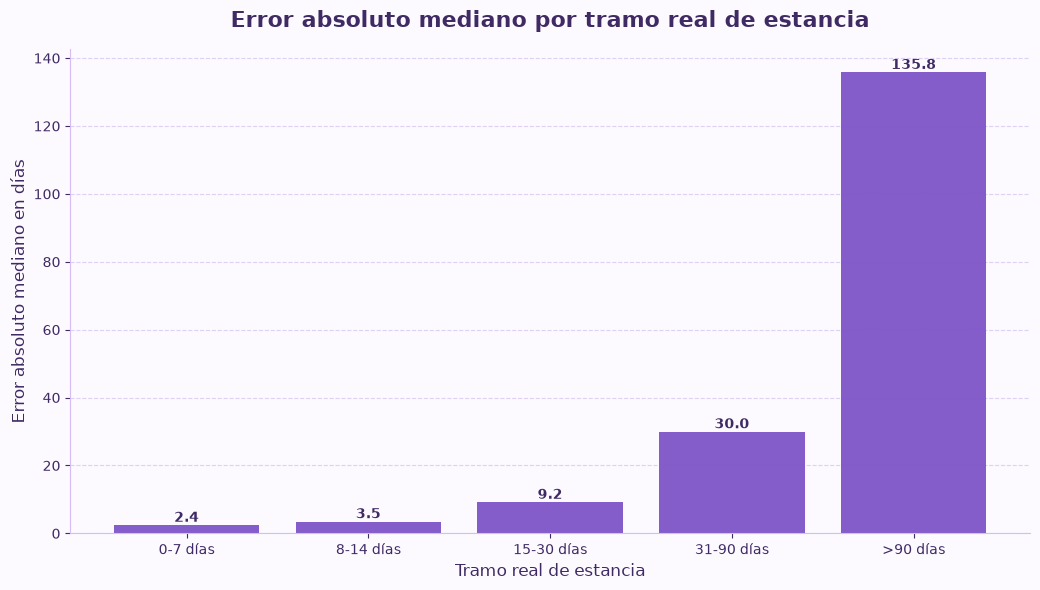

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\error_absoluto_mediano_por_tramo_estancia_regresion.png


In [121]:
# Gráfico de error absoluto mediano por tramo real de estancia

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    resumen_errores_por_tramo["tramo_estancia_real"].astype(str),
    resumen_errores_por_tramo["error_abs_mediano"],
    color="#6F42C1",
    alpha=0.85
)

for i, valor in enumerate(resumen_errores_por_tramo["error_abs_mediano"]):
    ax.text(
        i,
        valor,
        f"{valor:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Error absoluto mediano por tramo real de estancia",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Tramo real de estancia",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Error absoluto mediano en días",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64", rotation=0)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "error_absoluto_mediano_por_tramo_estancia_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

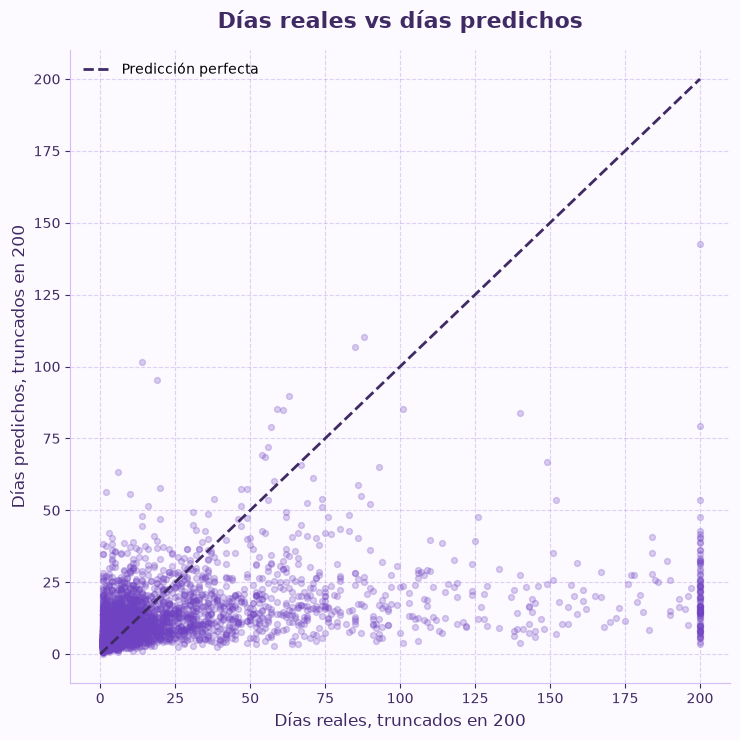

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\dias_reales_vs_predichos_regresion.png


In [122]:
# Gráfico de estancia real vs estancia predicha

muestra_plot = dogs_regresion_resultados_test.sample(
    n=min(5000, len(dogs_regresion_resultados_test)),
    random_state=RANDOM_STATE
).copy()

limite_plot = 200

fig, ax = plt.subplots(figsize=(7.5, 7.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.scatter(
    muestra_plot["stay_days_real"].clip(upper=limite_plot),
    muestra_plot["stay_days_pred"].clip(upper=limite_plot),
    alpha=0.25,
    color="#6F42C1",
    s=18
)

ax.plot(
    [0, limite_plot],
    [0, limite_plot],
    linestyle="--",
    color="#3F2A64",
    linewidth=2,
    label="Predicción perfecta"
)

ax.set_title(
    "Días reales vs días predichos",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    f"Días reales, truncados en {limite_plot}",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    f"Días predichos, truncados en {limite_plot}",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "dias_reales_vs_predichos_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

El análisis por tramos muestra que el modelo de regresión se comporta mejor en estancias cortas y medias que en estancias extremadamente largas.

Este patrón era esperable debido a la distribución de la variable objetivo. La mayoría de los perros presentan estancias relativamente breves, mientras que existe una cola larga de casos con estancias muy prolongadas. Estos casos extremos son difíciles de estimar con precisión mediante regresión, incluso cuando el modelo aprende cierta señal predictiva.

El gráfico de días reales frente a días predichos permite observar esta limitación: el modelo tiende a concentrar sus predicciones en rangos moderados y a infraestimar las estancias más largas.

Por tanto, la regresión aporta información complementaria sobre la duración aproximada esperada, pero confirma que la formulación de clasificación de larga estancia es más adecuada como herramienta principal de priorización.

## 5. Comparación con el modelo principal de clasificación

Una vez entrenado el modelo de regresión, se evalúa si sus predicciones de días pueden utilizarse también para identificar perros de larga estancia.

Para ello, se transforma la predicción continua de días en una predicción binaria: un perro se clasifica como larga estancia si la duración predicha es igual o superior a 30 días.

Este análisis permite comparar dos formulaciones del problema:

- el modelo principal de clasificación, entrenado directamente para detectar larga estancia;
- el modelo de regresión, entrenado para estimar días y convertido posteriormente en una regla binaria.

La comparación ayuda a determinar qué enfoque resulta más adecuado para el objetivo operativo de priorización.

In [123]:
# Funciones auxiliares para evaluación binaria

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def calcular_metricas_binarias(y_true, y_pred, y_score, nombre_modelo):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_score = np.asarray(y_score).astype(float)
    
    metricas = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if len(np.unique(y_score)) > 1:
        metricas["roc_auc"] = roc_auc_score(y_true, y_score)
        metricas["average_precision"] = average_precision_score(y_true, y_score)
    else:
        metricas["roc_auc"] = np.nan
        metricas["average_precision"] = np.nan
    
    return metricas

In [124]:
# Evaluación del modelo de regresión convertido a clasificador con umbral fijo de 30 días

y_true_long_stay_test = (
    dogs_regresion_resultados_test["target_long_stay"]
    .astype(int)
    .values
)

pred_larga_estancia_desde_regresion = (
    dogs_regresion_resultados_test["stay_days_pred"] >= 30
).astype(int)

score_larga_estancia_desde_regresion = (
    dogs_regresion_resultados_test["stay_days_pred"]
    .astype(float)
    .values
)

metricas_regresion_como_clasificador = calcular_metricas_binarias(
    y_true=y_true_long_stay_test,
    y_pred=pred_larga_estancia_desde_regresion,
    y_score=score_larga_estancia_desde_regresion,
    nombre_modelo="Regresión con umbral fijo 30 días"
)

metricas_regresion_como_clasificador_df = pd.DataFrame([
    metricas_regresion_como_clasificador
])

columnas_metricas_binarias = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision"
]

metricas_regresion_como_clasificador_df[columnas_metricas_binarias] = (
    metricas_regresion_como_clasificador_df[columnas_metricas_binarias]
    .round(4)
)

dogs_regresion_resultados_test["prediccion_larga_estancia_regresion_30d"] = (
    pred_larga_estancia_desde_regresion
)

print("Métricas de la regresión convertida a clasificación con umbral fijo de 30 días:")
display(metricas_regresion_como_clasificador_df)

print("Perros clasificados como larga estancia por la regresión con umbral fijo:")
print(pred_larga_estancia_desde_regresion.sum())
print("Porcentaje sobre test:", round(pred_larga_estancia_desde_regresion.mean() * 100, 2), "%")


Métricas de la regresión convertida a clasificación con umbral fijo de 30 días:


,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Regresión con umbral fijo 30 días,0.8576,0.6814,0.1638,0.2641,0.8252,0.49


Perros clasificados como larga estancia por la regresión con umbral fijo:
703
Porcentaje sobre test: 3.75 %


### 5.1. Optimización del umbral de días predichos

La conversión directa del modelo de regresión a una clasificación binaria mediante el umbral fijo de 30 días permite una primera comparación con el modelo principal. Sin embargo, esta comparación es conservadora para la regresión, ya que exige que el modelo prediga al menos 30 días para clasificar un caso como larga estancia.

Para realizar una comparación más justa, se busca un umbral operativo sobre los días predichos por la regresión utilizando el conjunto interno de validación. El criterio utilizado es maximizar el F1-score, de forma análoga al proceso de selección de umbral aplicado en la fase de modelización principal.

El umbral seleccionado en validación se aplica posteriormente sobre el conjunto de test.


In [125]:
# Búsqueda de umbral operativo para la regresión en el conjunto de validación

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

if tipo_mejor_modelo_regresion == "catboost":
    pred_mejor_log_val = modelo_catboost_reg_inicial.predict(X_val_catboost_reg)
elif tipo_mejor_modelo_regresion == "lightgbm":
    pred_mejor_log_val = modelo_mejor_regresion.predict(X_val_lgbm_reg)
else:
    raise ValueError("Tipo de modelo de regresión no reconocido.")

pred_mejor_dias_val = np.expm1(pred_mejor_log_val)
pred_mejor_dias_val = np.clip(pred_mejor_dias_val, a_min=0, a_max=None)

y_val_long_stay = (
    dogs_regresion_val[variable_objetivo_regresion]
    .astype(float)
    .ge(30)
    .astype(int)
    .values
)

umbrales_dias_regresion = np.arange(1, 91, 1)

resultados_umbrales_regresion = []

for umbral in umbrales_dias_regresion:
    y_pred_val_umbral = (pred_mejor_dias_val >= umbral).astype(int)
    
    resultados_umbrales_regresion.append({
        "umbral_dias_predichos": umbral,
        "accuracy": accuracy_score(y_val_long_stay, y_pred_val_umbral),
        "precision": precision_score(y_val_long_stay, y_pred_val_umbral, zero_division=0),
        "recall": recall_score(y_val_long_stay, y_pred_val_umbral, zero_division=0),
        "f1_score": f1_score(y_val_long_stay, y_pred_val_umbral, zero_division=0),
        "n_predichos_larga_estancia": int(y_pred_val_umbral.sum()),
        "pct_predichos_larga_estancia": float(y_pred_val_umbral.mean())
    })

tabla_umbrales_regresion = pd.DataFrame(resultados_umbrales_regresion)

tabla_umbrales_regresion = tabla_umbrales_regresion.sort_values(
    ["f1_score", "recall", "precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

umbral_regresion_optimizado = int(
    tabla_umbrales_regresion.loc[0, "umbral_dias_predichos"]
)

print("Mejor umbral de días predichos para la regresión:")
print(umbral_regresion_optimizado)

print("\nTop 10 umbrales por F1-score en validación:")
display(
    tabla_umbrales_regresion
    .head(10)
    .round(4)
)


Mejor umbral de días predichos para la regresión:
12

Top 10 umbrales por F1-score en validación:


,umbral_dias_predichos,accuracy,precision,recall,f1_score,n_predichos_larga_estancia,pct_predichos_larga_estancia
0,12,0.7646,0.3799,0.6549,0.4808,3217,0.2869
1,13,0.7813,0.3956,0.5949,0.4752,2806,0.2503
2,11,0.7402,0.3561,0.6945,0.4708,3639,0.3246
3,14,0.7951,0.4125,0.5445,0.4694,2463,0.2197
4,10,0.7136,0.3376,0.7492,0.4655,4141,0.3693
5,15,0.8057,0.4282,0.5000,0.4613,2179,0.1943
6,9,0.6812,0.3181,0.8001,0.4552,4694,0.4187
7,16,0.8152,0.4460,0.4555,0.4507,1906,0.1700
8,17,0.8228,0.4640,0.4180,0.4398,1681,0.1499
9,8,0.6310,0.2905,0.8435,0.4321,5419,0.4833


In [126]:
# Evaluación de la regresión como clasificador usando el umbral optimizado en validación

pred_larga_estancia_desde_regresion_umbral_optimizado = (
    dogs_regresion_resultados_test["stay_days_pred"] >= umbral_regresion_optimizado
).astype(int)

metricas_regresion_umbral_optimizado = calcular_metricas_binarias(
    y_true=y_true_long_stay_test,
    y_pred=pred_larga_estancia_desde_regresion_umbral_optimizado,
    y_score=score_larga_estancia_desde_regresion,
    nombre_modelo=f"Regresión con umbral optimizado ({umbral_regresion_optimizado} días)"
)

metricas_regresion_umbral_optimizado_df = pd.DataFrame([
    metricas_regresion_umbral_optimizado
])

metricas_regresion_umbral_optimizado_df[columnas_metricas_binarias] = (
    metricas_regresion_umbral_optimizado_df[columnas_metricas_binarias]
    .round(4)
)

dogs_regresion_resultados_test["prediccion_larga_estancia_regresion_umbral_optimizado"] = (
    pred_larga_estancia_desde_regresion_umbral_optimizado
)

print("Métricas de la regresión con umbral optimizado en validación:")
display(metricas_regresion_umbral_optimizado_df)

print("Perros clasificados como larga estancia por la regresión con umbral optimizado:")
print(pred_larga_estancia_desde_regresion_umbral_optimizado.sum())
print(
    "Porcentaje sobre test:",
    round(pred_larga_estancia_desde_regresion_umbral_optimizado.mean() * 100, 2),
    "%"
)


Métricas de la regresión con umbral optimizado en validación:


,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Regresión con umbral optimizado (12 días),0.7747,0.3809,0.7104,0.4959,0.8252,0.49


Perros clasificados como larga estancia por la regresión con umbral optimizado:
5455
Porcentaje sobre test: 29.09 %


In [127]:
# Reconstrucción de predicciones del modelo principal de clasificación

modelo_catboost_clasificacion = modelo_final_guardado["modelo_catboost"]
modelo_lgbm_clasificacion = modelo_final_guardado["modelo_lgbm"]

peso_catboost = modelo_final_guardado["peso_catboost"]
peso_lgbm = modelo_final_guardado["peso_lgbm"]
umbral_decision = modelo_final_guardado["umbral_decision"]
usar_ensemble = modelo_final_guardado["usar_ensemble"]

def preparar_datos_catboost_clasificacion(df, variables, variables_categoricas):
    X = df[variables].copy()
    
    for col in variables_categoricas:
        if col in X.columns:
            X[col] = (
                X[col]
                .fillna("Sin información")
                .astype(str)
            )
    
    return X


X_test_catboost_clasificacion = preparar_datos_catboost_clasificacion(
    dogs_regresion_test,
    variables_catboost_clasificacion,
    variables_categoricas_catboost
)

X_test_lgbm_clasificacion = dogs_regresion_test[
    variables_lgbm_clasificacion
].copy()

proba_catboost_clasificacion_test = (
    modelo_catboost_clasificacion
    .predict_proba(X_test_catboost_clasificacion)[:, 1]
)

proba_lgbm_clasificacion_test = (
    modelo_lgbm_clasificacion
    .predict_proba(X_test_lgbm_clasificacion)[:, 1]
)

if usar_ensemble:
    proba_modelo_principal_test = (
        peso_catboost * proba_catboost_clasificacion_test
        + peso_lgbm * proba_lgbm_clasificacion_test
    )
else:
    proba_modelo_principal_test = proba_catboost_clasificacion_test

pred_modelo_principal_test = (
    proba_modelo_principal_test >= umbral_decision
).astype(int)

metricas_modelo_principal_clasificacion = calcular_metricas_binarias(
    y_true=y_true_long_stay_test,
    y_pred=pred_modelo_principal_test,
    y_score=proba_modelo_principal_test,
    nombre_modelo="Modelo principal de clasificación"
)

metricas_modelo_principal_clasificacion_df = pd.DataFrame([
    metricas_modelo_principal_clasificacion
])

metricas_modelo_principal_clasificacion_df[columnas_metricas_binarias] = (
    metricas_modelo_principal_clasificacion_df[columnas_metricas_binarias]
    .round(4)
)

print("Métricas del modelo principal de clasificación:")
display(metricas_modelo_principal_clasificacion_df)

print("Umbral de decisión del modelo principal:", umbral_decision)
print("Perros clasificados como larga estancia por el modelo principal:")
print(pred_modelo_principal_test.sum())
print("Porcentaje sobre test:", round(pred_modelo_principal_test.mean() * 100, 2), "%")

Métricas del modelo principal de clasificación:


,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Modelo principal de clasificación,0.8242,0.457,0.6756,0.5452,0.8593,0.5721


Umbral de decisión del modelo principal: 0.24
Perros clasificados como larga estancia por el modelo principal:
4324
Porcentaje sobre test: 23.06 %


In [128]:
# Comparación entre clasificación principal, regresión con umbral fijo y regresión con umbral optimizado

comparacion_clasificacion_vs_regresion = pd.concat(
    [
        metricas_modelo_principal_clasificacion_df,
        metricas_regresion_como_clasificador_df,
        metricas_regresion_umbral_optimizado_df
    ],
    ignore_index=True
)

comparacion_clasificacion_vs_regresion[columnas_metricas_binarias] = (
    comparacion_clasificacion_vs_regresion[columnas_metricas_binarias]
    .round(4)
)

print("Comparación entre modelo principal de clasificación y regresión convertida a clasificación:")
display(comparacion_clasificacion_vs_regresion)

# Relación entre score principal y días predichos por regresión
correlacion_score_regresion = pd.Series(
    proba_modelo_principal_test
).corr(
    pd.Series(score_larga_estancia_desde_regresion),
    method="spearman"
)

print(
    "\nCorrelación de Spearman entre la probabilidad del modelo principal "
    "y los días predichos por la regresión:"
)
print(round(correlacion_score_regresion, 4))


Comparación entre modelo principal de clasificación y regresión convertida a clasificación:


,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Modelo principal de clasificación,0.8242,0.4570,0.6756,0.5452,0.8593,0.5721
1,Regresión con umbral fijo 30 días,0.8576,0.6814,0.1638,0.2641,0.8252,0.4900
2,Regresión con umbral optimizado (12 días),0.7747,0.3809,0.7104,0.4959,0.8252,0.4900



Correlación de Spearman entre la probabilidad del modelo principal y los días predichos por la regresión:
0.7972


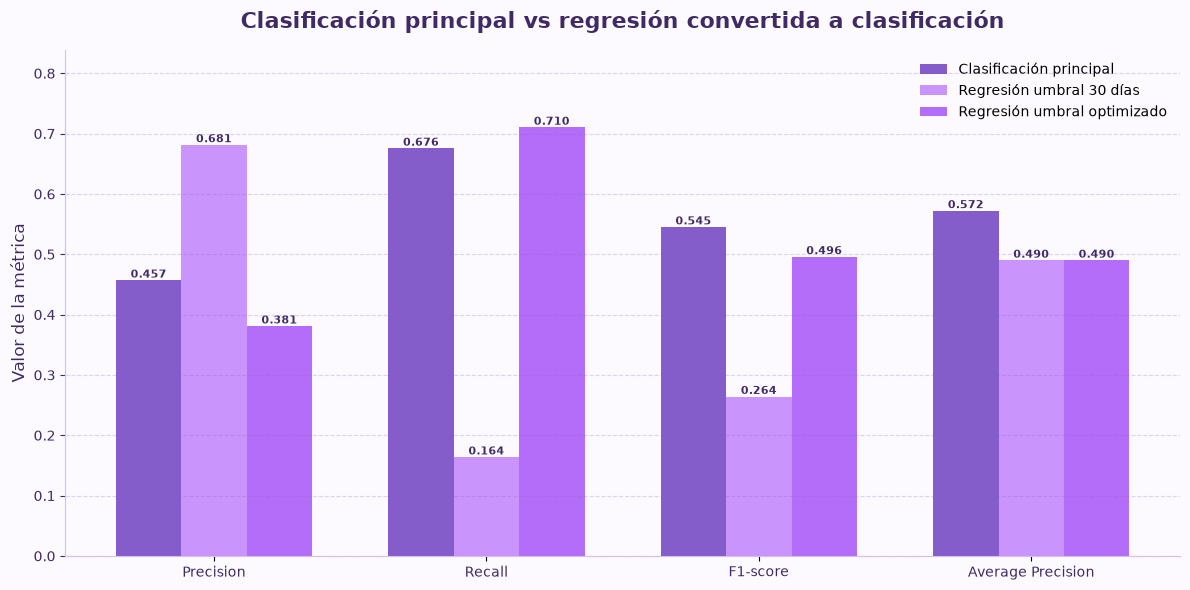

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\comparacion_clasificacion_principal_vs_regresion_convertida.png


In [129]:
# Gráfico comparativo entre clasificación principal y regresión convertida

metricas_para_plot = ["precision", "recall", "f1_score", "average_precision"]

datos_plot_comparacion = (
    comparacion_clasificacion_vs_regresion
    .set_index("modelo")[metricas_para_plot]
    .T
)

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(metricas_para_plot))
modelos_plot = datos_plot_comparacion.columns.tolist()
ancho = 0.24

offsets = np.linspace(
    -ancho * (len(modelos_plot) - 1) / 2,
    ancho * (len(modelos_plot) - 1) / 2,
    len(modelos_plot)
)

colores_modelos = {
    "Modelo principal de clasificación": "#6F42C1",
    "Regresión con umbral fijo 30 días": "#C084FC",
    f"Regresión con umbral optimizado ({umbral_regresion_optimizado} días)": "#A855F7"
}

etiquetas_modelos = {
    "Modelo principal de clasificación": "Clasificación principal",
    "Regresión con umbral fijo 30 días": "Regresión umbral 30 días",
    f"Regresión con umbral optimizado ({umbral_regresion_optimizado} días)": "Regresión umbral optimizado"
}

for offset, modelo in zip(offsets, modelos_plot):
    valores = datos_plot_comparacion[modelo].values
    
    ax.bar(
        x + offset,
        valores,
        width=ancho,
        color=colores_modelos.get(modelo, "#8B5CF6"),
        alpha=0.85,
        label=etiquetas_modelos.get(modelo, modelo)
    )
    
    for i, valor in enumerate(valores):
        ax.text(
            i + offset,
            valor,
            f"{valor:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Clasificación principal vs regresión convertida a clasificación",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xticks(x)
ax.set_xticklabels(
    ["Precision", "Recall", "F1-score", "Average Precision"],
    color="#3F2A64"
)

ax.set_ylabel(
    "Valor de la métrica",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0, max(datos_plot_comparacion.max()) * 1.18)

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False, loc="upper right")

fig.tight_layout()

fig_path = figures_path / "comparacion_clasificacion_principal_vs_regresion_convertida.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)


La comparación entre clasificación y regresión muestra que la forma de convertir la regresión en una predicción binaria influye de forma importante en los resultados.

Con el umbral fijo de 30 días predichos, la regresión se comporta de forma muy conservadora: clasifica pocos perros como larga estancia, obtiene una precision elevada, pero un recall bajo.

Para realizar una comparación más justa, se ha buscado un umbral operativo sobre los días predichos utilizando el conjunto interno de validación. Este umbral permite equilibrar mejor precision y recall, siguiendo un criterio más comparable al empleado en el modelo principal de clasificación.

Aun así, el modelo principal de clasificación se mantiene como la formulación más adecuada para el objetivo central del proyecto, ya que fue entrenado directamente para detectar perros con riesgo de larga estancia. La regresión se mantiene como una señal complementaria de severidad aproximada, no como sustituto del Invisible Dog Score.


## 6. Comparación Top-K entre clasificación y regresión

Además de comparar ambos enfoques mediante métricas binarias, se evalúa su capacidad como ranking operativo.

En este análisis se ordenan los perros del conjunto de test según:

- la probabilidad estimada por el modelo principal de clasificación;
- los días estimados por el modelo de regresión.

Posteriormente, se analizan distintos segmentos Top-K para comprobar qué enfoque concentra mejor los casos reales de larga estancia en las primeras posiciones del ranking.

In [130]:
# Comparación Top-K entre modelo principal y regresión

def calcular_metricas_topk_ranking(y_true, score, nombre_modelo, segmentos_topk=None):
    if segmentos_topk is None:
        segmentos_topk = [0.01, 0.05, 0.10, 0.20, 0.30]
    
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)
    
    datos = pd.DataFrame({
        "y_true": y_true,
        "score": score
    }).sort_values("score", ascending=False).reset_index(drop=True)
    
    total_registros = len(datos)
    total_positivos = datos["y_true"].sum()
    tasa_base = datos["y_true"].mean()
    
    resultados = []
    
    for porcentaje in segmentos_topk:
        n_priorizados = int(np.ceil(total_registros * porcentaje))
        topk = datos.head(n_priorizados)
        
        casos_detectados = topk["y_true"].sum()
        precision_topk = casos_detectados / n_priorizados
        recall_topk = casos_detectados / total_positivos
        lift_topk = precision_topk / tasa_base
        
        resultados.append({
            "modelo": nombre_modelo,
            "segmento_priorizado": f"Top {int(porcentaje * 100)}%",
            "porcentaje_priorizado": porcentaje,
            "n_perros_priorizados": n_priorizados,
            "casos_larga_estancia_detectados": casos_detectados,
            "precision_topk": precision_topk,
            "recall_topk": recall_topk,
            "lift_topk": lift_topk,
            "tasa_base_larga_estancia": tasa_base
        })
    
    return pd.DataFrame(resultados)


topk_modelo_principal = calcular_metricas_topk_ranking(
    y_true=y_true_long_stay_test,
    score=proba_modelo_principal_test,
    nombre_modelo="Modelo principal de clasificación"
)

topk_regresion = calcular_metricas_topk_ranking(
    y_true=y_true_long_stay_test,
    score=score_larga_estancia_desde_regresion,
    nombre_modelo="Regresión por días estimados"
)

comparacion_topk_clasificacion_regresion = pd.concat(
    [
        topk_modelo_principal,
        topk_regresion
    ],
    ignore_index=True
)

columnas_redondear_topk_comparacion = [
    "porcentaje_priorizado",
    "precision_topk",
    "recall_topk",
    "lift_topk",
    "tasa_base_larga_estancia"
]

comparacion_topk_clasificacion_regresion[columnas_redondear_topk_comparacion] = (
    comparacion_topk_clasificacion_regresion[columnas_redondear_topk_comparacion]
    .round(4)
)

print("Comparación Top-K entre modelo principal y regresión:")
display(comparacion_topk_clasificacion_regresion)

Comparación Top-K entre modelo principal y regresión:


,modelo,segmento_priorizado,porcentaje_priorizado,n_perros_priorizados,casos_larga_estancia_detectados,precision_topk,recall_topk,lift_topk,tasa_base_larga_estancia
0,Modelo principal de clasificación,Top 1%,0.01,188,186,0.9894,0.0636,6.3427,0.156
1,Modelo principal de clasificación,Top 5%,0.05,938,674,0.7186,0.2304,4.6066,0.156
2,Modelo principal de clasificación,Top 10%,0.10,1876,1145,0.6103,0.3915,3.9129,0.156
3,Modelo principal de clasificación,Top 20%,0.20,3751,1819,0.4849,0.6219,3.1089,0.156
4,Modelo principal de clasificación,Top 30%,0.30,5626,2258,0.4014,0.7720,2.5730,0.156
5,Regresión por días estimados,Top 1%,0.01,188,155,0.8245,0.0530,5.2856,0.156
6,Regresión por días estimados,Top 5%,0.05,938,603,0.6429,0.2062,4.1213,0.156
7,Regresión por días estimados,Top 10%,0.10,1876,1021,0.5442,0.3491,3.4891,0.156
8,Regresión por días estimados,Top 20%,0.20,3751,1673,0.4460,0.5720,2.8594,0.156
9,Regresión por días estimados,Top 30%,0.30,5626,2105,0.3742,0.7197,2.3987,0.156


In [131]:
# Tabla comparativa Top-K en formato ancho

orden_segmentos_topk = ["Top 1%", "Top 5%", "Top 10%", "Top 20%", "Top 30%"]

comparacion_topk_clasificacion_regresion["segmento_priorizado"] = pd.Categorical(
    comparacion_topk_clasificacion_regresion["segmento_priorizado"],
    categories=orden_segmentos_topk,
    ordered=True
)

comparacion_topk_pivot = (
    comparacion_topk_clasificacion_regresion
    .pivot_table(
        index="segmento_priorizado",
        columns="modelo",
        values=["precision_topk", "recall_topk", "lift_topk"],
        aggfunc="first",
        observed=False
    )
    .sort_index()
)

print("Comparación Top-K en formato resumido:")
display(comparacion_topk_pivot)

Comparación Top-K en formato resumido:


lift_topk                                                 precision_topk                               \
modelo              Modelo principal de clasificación Regresión por días estimados Modelo principal de clasificación Regresión por días estimados   
segmento_priorizado                                                                                                                                 
Top 1%                                         6.3427                       5.2856                            0.9894                       0.8245   
Top 5%                                         4.6066                       4.1213                            0.7186                       0.6429   
Top 10%                                        3.9129                       3.4891                            0.6103                       0.5442   
Top 20%                                        3.1089                       2.8594                            0.4849                       0.4460   
Top 30%                                        2.5730                       2.3987                            0.4014                       0.3742   

                                          recall_topk                               
modelo              Modelo principal de clasificación Regresión por días estimados  
segmento_priorizado                                                                 
Top 1%                                         0.0636                       0.0530  
Top 5%                                         0.2304                       0.2062  
Top 10%                                        0.3915                       0.3491  
Top 20%                                        0.6219                       0.5720  
Top 30%                                        0.7720                       0.7197

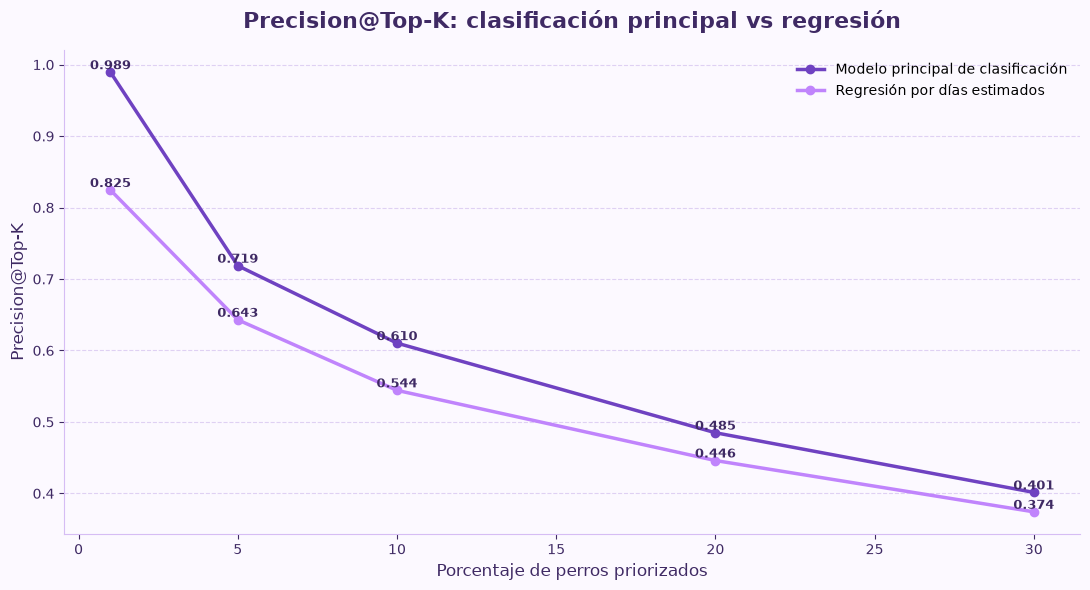

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\precision_topk_clasificacion_vs_regresion.png


In [132]:
# Gráfico comparativo de Precision@Top-K

datos_plot_topk_precision = comparacion_topk_clasificacion_regresion.copy()

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

for modelo, color in {
    "Modelo principal de clasificación": "#6F42C1",
    "Regresión por días estimados": "#C084FC"
}.items():
    datos_modelo = datos_plot_topk_precision.loc[
        datos_plot_topk_precision["modelo"] == modelo
    ].copy()
    
    ax.plot(
        datos_modelo["porcentaje_priorizado"] * 100,
        datos_modelo["precision_topk"],
        marker="o",
        linewidth=2.5,
        color=color,
        label=modelo
    )
    
    for _, fila in datos_modelo.iterrows():
        ax.text(
            fila["porcentaje_priorizado"] * 100,
            fila["precision_topk"],
            f"{fila['precision_topk']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Precision@Top-K: clasificación principal vs regresión",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Porcentaje de perros priorizados",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Precision@Top-K",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "precision_topk_clasificacion_vs_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

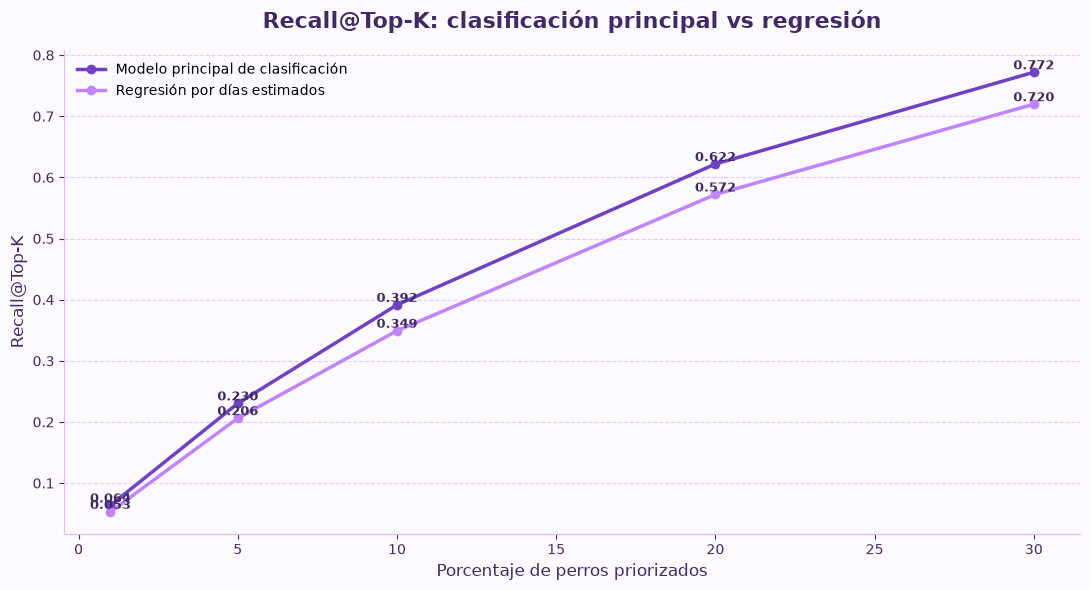

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\recall_topk_clasificacion_vs_regresion.png


In [133]:
# Gráfico comparativo de Recall@Top-K

datos_plot_topk_recall = comparacion_topk_clasificacion_regresion.copy()

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

for modelo, color in {
    "Modelo principal de clasificación": "#6F42C1",
    "Regresión por días estimados": "#C084FC"
}.items():
    datos_modelo = datos_plot_topk_recall.loc[
        datos_plot_topk_recall["modelo"] == modelo
    ].copy()
    
    ax.plot(
        datos_modelo["porcentaje_priorizado"] * 100,
        datos_modelo["recall_topk"],
        marker="o",
        linewidth=2.5,
        color=color,
        label=modelo
    )
    
    for _, fila in datos_modelo.iterrows():
        ax.text(
            fila["porcentaje_priorizado"] * 100,
            fila["recall_topk"],
            f"{fila['recall_topk']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Recall@Top-K: clasificación principal vs regresión",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Porcentaje de perros priorizados",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Recall@Top-K",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "recall_topk_clasificacion_vs_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

El análisis Top-K confirma que ambos enfoques contienen señal predictiva, pero el modelo principal de clasificación mantiene una mejor capacidad de priorización.

En todos los segmentos analizados, la clasificación principal concentra más casos reales de larga estancia que la regresión ordenada por días estimados. Por ejemplo, en el Top 10 %, el modelo principal detecta 1.145 casos reales de larga estancia, frente a 1.021 casos detectados por la regresión. En el Top 30 %, la clasificación detecta 2.258 casos, frente a 2.105 en la regresión.

Estos resultados indican que la regresión genera un ranking razonable, pero no supera al modelo entrenado directamente para clasificar larga estancia. La diferencia es coherente con los resultados anteriores: la regresión tiende a infraestimar las estancias más largas y, por tanto, pierde capacidad para priorizar algunos casos relevantes.

Aun así, la regresión aporta valor complementario. La elevada correlación entre la probabilidad del modelo principal y los días predichos por la regresión muestra que ambos enfoques capturan patrones relacionados. Por tanto, la clasificación debe mantenerse como herramienta principal de detección, mientras que la regresión puede utilizarse como señal secundaria de severidad aproximada.

## 7. Severidad estimada de la estancia

Aunque la regresión no supera al modelo principal como herramienta de detección de larga estancia, sí puede aportar una señal complementaria sobre la duración aproximada esperada.

En esta sección se transforma la predicción continua de días en tramos de severidad estimada. El objetivo es analizar si los días predichos permiten diferenciar perros con una estancia esperada baja, moderada o elevada.

Esta información puede utilizarse como apoyo adicional al Invisible Dog Score, especialmente para distinguir entre perros con riesgo similar pero distinta severidad estimada.

In [134]:
# Creación de tramos de severidad estimada a partir de los días predichos

bins_severidad_predicha = [-0.01, 7, 14, 30, 60, np.inf]

labels_severidad_predicha = [
    "Muy baja: 0-7 días",
    "Baja: 8-14 días",
    "Media: 15-30 días",
    "Alta: 31-60 días",
    "Muy alta: >60 días"
]

dogs_regresion_resultados_test["severidad_estancia_predicha"] = pd.cut(
    dogs_regresion_resultados_test["stay_days_pred"],
    bins=bins_severidad_predicha,
    labels=labels_severidad_predicha
)

resumen_severidad_predicha = (
    dogs_regresion_resultados_test
    .groupby("severidad_estancia_predicha", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        porcentaje_perros=("animal_id", lambda x: len(x) / len(dogs_regresion_resultados_test) * 100),
        estancia_real_media=("stay_days_real", "mean"),
        estancia_real_mediana=("stay_days_real", "median"),
        prediccion_media=("stay_days_pred", "mean"),
        prediccion_mediana=("stay_days_pred", "median"),
        tasa_real_larga_estancia=("target_long_stay", "mean"),
        error_abs_medio=("error_abs", "mean"),
        error_abs_mediano=("error_abs", "median")
    )
    .reset_index()
)

columnas_redondear_severidad = [
    "porcentaje_perros",
    "estancia_real_media",
    "estancia_real_mediana",
    "prediccion_media",
    "prediccion_mediana",
    "tasa_real_larga_estancia",
    "error_abs_medio",
    "error_abs_mediano"
]

resumen_severidad_predicha[columnas_redondear_severidad] = (
    resumen_severidad_predicha[columnas_redondear_severidad]
    .round(4)
)

print("Resumen por severidad estimada de estancia:")
display(resumen_severidad_predicha)

Resumen por severidad estimada de estancia:


,severidad_estancia_predicha,n_perros,porcentaje_perros,estancia_real_media,estancia_real_mediana,prediccion_media,prediccion_mediana,tasa_real_larga_estancia,error_abs_medio,error_abs_mediano
0,Muy baja: 0-7 días,8295,44.2353,7.8832,4.0,4.5666,4.6638,0.0316,5.6604,1.9422
1,Baja: 8-14 días,6224,33.1911,19.9099,8.0,9.8821,9.5416,0.1387,15.4746,5.2685
2,Media: 15-30 días,3530,18.8247,46.1297,19.0,19.2882,18.2492,0.3742,37.0765,13.2406
3,Alta: 31-60 días,633,3.3756,77.7188,49.0,39.1768,36.8554,0.6667,56.1099,25.6707
4,Muy alta: >60 días,70,0.3733,72.7000,61.0,74.5160,70.1737,0.8143,37.2024,19.5302


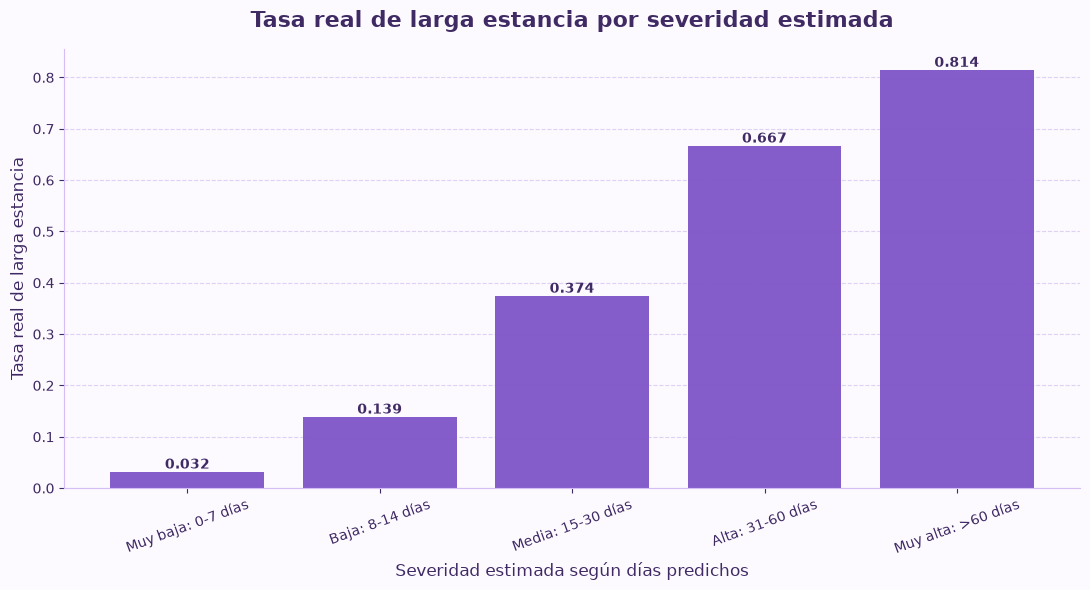

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\tasa_larga_estancia_por_severidad_predicha_regresion.png


In [135]:
# Tasa real de larga estancia por severidad estimada

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    resumen_severidad_predicha["severidad_estancia_predicha"].astype(str),
    resumen_severidad_predicha["tasa_real_larga_estancia"],
    color="#6F42C1",
    alpha=0.85
)

for i, valor in enumerate(resumen_severidad_predicha["tasa_real_larga_estancia"]):
    ax.text(
        i,
        valor,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Tasa real de larga estancia por severidad estimada",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Severidad estimada según días predichos",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Tasa real de larga estancia",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64", rotation=20)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "tasa_larga_estancia_por_severidad_predicha_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

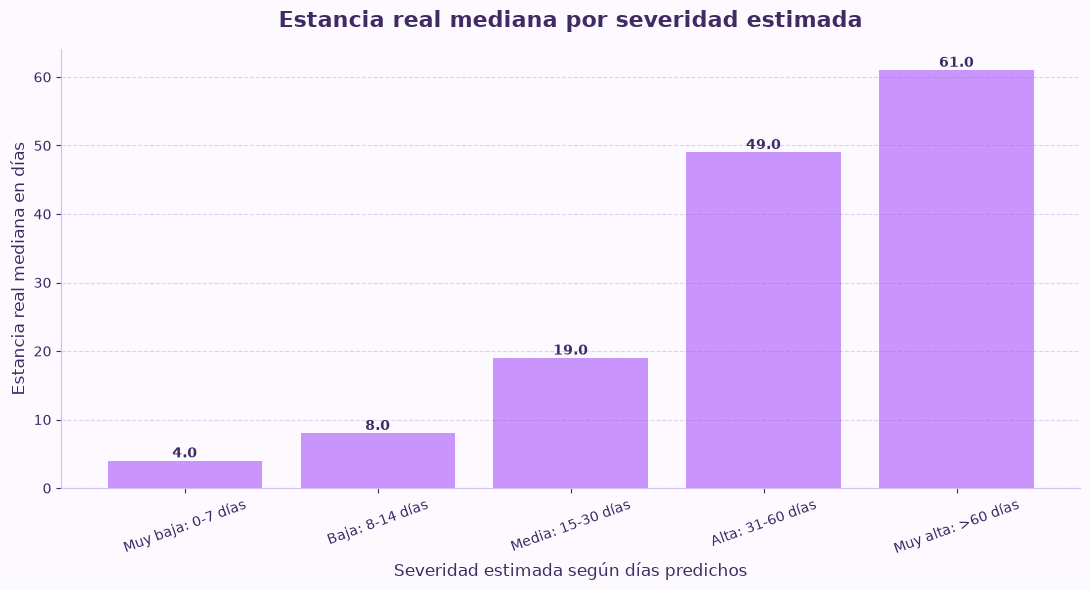

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\estancia_real_mediana_por_severidad_predicha_regresion.png


In [136]:
# Estancia real mediana por severidad estimada

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    resumen_severidad_predicha["severidad_estancia_predicha"].astype(str),
    resumen_severidad_predicha["estancia_real_mediana"],
    color="#C084FC",
    alpha=0.85
)

for i, valor in enumerate(resumen_severidad_predicha["estancia_real_mediana"]):
    ax.text(
        i,
        valor,
        f"{valor:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Estancia real mediana por severidad estimada",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Severidad estimada según días predichos",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Estancia real mediana en días",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64", rotation=20)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "estancia_real_mediana_por_severidad_predicha_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

La agrupación por severidad estimada confirma que la regresión aporta información complementaria útil.

A medida que aumentan los días predichos por el modelo de regresión, también aumenta la tasa real de larga estancia. La tasa pasa del 3,2 % en el grupo de severidad muy baja al 81,4 % en el grupo de severidad muy alta.

Además, la estancia real mediana también crece de forma progresiva, desde 4 días en el grupo de severidad muy baja hasta 61 días en el grupo de severidad muy alta.

Estos resultados muestran que, aunque la regresión no sea la mejor formulación para detectar todos los perros de larga estancia, sí permite construir una señal secundaria de severidad. Esta señal puede complementar al Invisible Dog Score, ayudando a diferenciar perros con una duración esperada más o menos elevada dentro de niveles de riesgo similares.

## 8. Combinación del Invisible Dog Score con la severidad estimada

En esta sección se combinan los dos enfoques desarrollados:

- el Invisible Dog Score, procedente del modelo principal de clasificación;
- la severidad estimada de estancia, procedente del modelo de regresión.

El objetivo no es crear un nuevo modelo que sustituya al clasificador principal, sino construir una lectura operativa más rica. De esta forma, el score permite priorizar perros con riesgo de larga estancia, mientras que la regresión aporta una señal adicional sobre la duración aproximada esperada.

In [137]:
# Combinación del Invisible Dog Score con la severidad estimada

def asignar_banda_riesgo_score(score):
    if score < 25:
        return "Bajo riesgo"
    elif score < 50:
        return "Riesgo medio"
    elif score < 75:
        return "Riesgo alto"
    else:
        return "Riesgo crítico"


orden_bandas_riesgo = [
    "Bajo riesgo",
    "Riesgo medio",
    "Riesgo alto",
    "Riesgo crítico"
]

orden_severidad_predicha = [
    "Muy baja: 0-7 días",
    "Baja: 8-14 días",
    "Media: 15-30 días",
    "Alta: 31-60 días",
    "Muy alta: >60 días"
]

dogs_regresion_resultados_test["probabilidad_larga_estancia_modelo_principal"] = (
    proba_modelo_principal_test
)

dogs_regresion_resultados_test["invisible_dog_score"] = (
    dogs_regresion_resultados_test["probabilidad_larga_estancia_modelo_principal"] * 100
).round(1)

dogs_regresion_resultados_test["banda_riesgo_clasificacion"] = (
    dogs_regresion_resultados_test["invisible_dog_score"]
    .apply(asignar_banda_riesgo_score)
)

dogs_regresion_resultados_test["banda_riesgo_clasificacion"] = pd.Categorical(
    dogs_regresion_resultados_test["banda_riesgo_clasificacion"],
    categories=orden_bandas_riesgo,
    ordered=True
)

dogs_regresion_resultados_test["severidad_estancia_predicha"] = pd.Categorical(
    dogs_regresion_resultados_test["severidad_estancia_predicha"],
    categories=orden_severidad_predicha,
    ordered=True
)

dogs_regresion_resultados_test["prediccion_larga_estancia_modelo_principal"] = (
    pred_modelo_principal_test
)

dogs_regresion_resultados_test["prediccion_larga_estancia_regresion_30d"] = (
    pred_larga_estancia_desde_regresion
)

dogs_regresion_resultados_test["prediccion_larga_estancia_regresion_umbral_optimizado"] = (
    pred_larga_estancia_desde_regresion_umbral_optimizado
)

print("Tabla combinada score + severidad creada correctamente.")
display(
    dogs_regresion_resultados_test[
        [
            "animal_id",
            "stay_days_real",
            "target_long_stay",
            "invisible_dog_score",
            "banda_riesgo_clasificacion",
            "stay_days_pred",
            "severidad_estancia_predicha",
            "prediccion_larga_estancia_modelo_principal",
            "prediccion_larga_estancia_regresion_30d",
            "prediccion_larga_estancia_regresion_umbral_optimizado"
        ]
    ].head(10)
)

Tabla combinada score + severidad creada correctamente.


,animal_id,stay_days_real,target_long_stay,invisible_dog_score,banda_riesgo_clasificacion,stay_days_pred,severidad_estancia_predicha,prediccion_larga_estancia_modelo_principal,prediccion_larga_estancia_regresion_30d,prediccion_larga_estancia_regresion_umbral_optimizado
37,A271790,7,0,4.9,Bajo riesgo,3.228906,Muy baja: 0-7 días,0,0,0
41,A280390,1,0,2.9,Bajo riesgo,2.797344,Muy baja: 0-7 días,0,0,0
80,A329257,4,0,2.1,Bajo riesgo,4.819781,Muy baja: 0-7 días,0,0,0
94,A337187,10,0,14.2,Bajo riesgo,8.267950,Baja: 8-14 días,0,0,0
103,A339103,1,0,12.8,Bajo riesgo,3.808040,Muy baja: 0-7 días,0,0,0
106,A342473,1,0,5.0,Bajo riesgo,4.310516,Muy baja: 0-7 días,0,0,0
116,A348272,6,0,13.2,Bajo riesgo,3.737714,Muy baja: 0-7 días,0,0,0
119,A349480,8,0,5.4,Bajo riesgo,5.613701,Muy baja: 0-7 días,0,0,0
120,A349733,3,0,4.7,Bajo riesgo,2.471621,Muy baja: 0-7 días,0,0,0
124,A354725,4,0,10.3,Bajo riesgo,4.457906,Muy baja: 0-7 días,0,0,0


In [138]:
# Matriz entre banda de riesgo del modelo principal y severidad estimada por regresión

matriz_riesgo_severidad = (
    dogs_regresion_resultados_test
    .groupby(
        ["banda_riesgo_clasificacion", "severidad_estancia_predicha"],
        observed=False
    )
    .agg(
        n_perros=("animal_id", "count"),
        porcentaje_perros=("animal_id", lambda x: len(x) / len(dogs_regresion_resultados_test) * 100),
        score_medio=("invisible_dog_score", "mean"),
        dias_predichos_mediana=("stay_days_pred", "median"),
        estancia_real_mediana=("stay_days_real", "median"),
        tasa_real_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

columnas_redondear_matriz = [
    "porcentaje_perros",
    "score_medio",
    "dias_predichos_mediana",
    "estancia_real_mediana",
    "tasa_real_larga_estancia"
]

matriz_riesgo_severidad[columnas_redondear_matriz] = (
    matriz_riesgo_severidad[columnas_redondear_matriz]
    .round(4)
)

print("Matriz de banda de riesgo y severidad estimada:")
display(matriz_riesgo_severidad)

Matriz de banda de riesgo y severidad estimada:


,banda_riesgo_clasificacion,severidad_estancia_predicha,n_perros,porcentaje_perros,score_medio,dias_predichos_mediana,estancia_real_mediana,tasa_real_larga_estancia
0,Bajo riesgo,Muy baja: 0-7 días,8260,44.0486,4.8509,4.6558,4.0,0.0314
1,Bajo riesgo,Baja: 8-14 días,5402,28.8076,11.4904,9.2585,8.0,0.1074
2,Bajo riesgo,Media: 15-30 días,930,4.9595,15.0618,16.1712,12.0,0.1645
3,Bajo riesgo,Alta: 31-60 días,18,0.0960,12.8778,33.8145,13.5,0.0556
4,Bajo riesgo,Muy alta: >60 días,0,0.0000,NaN,NaN,NaN,NaN
5,Riesgo medio,Muy baja: 0-7 días,33,0.1760,29.8606,6.0268,2.0,0.0606
6,Riesgo medio,Baja: 8-14 días,781,4.1649,31.1183,11.7594,11.0,0.3252
7,Riesgo medio,Media: 15-30 días,2111,11.2575,36.6346,18.2758,21.0,0.4031
8,Riesgo medio,Alta: 31-60 días,88,0.4693,41.4273,33.5059,33.0,0.5341
9,Riesgo medio,Muy alta: >60 días,0,0.0000,NaN,NaN,NaN,NaN


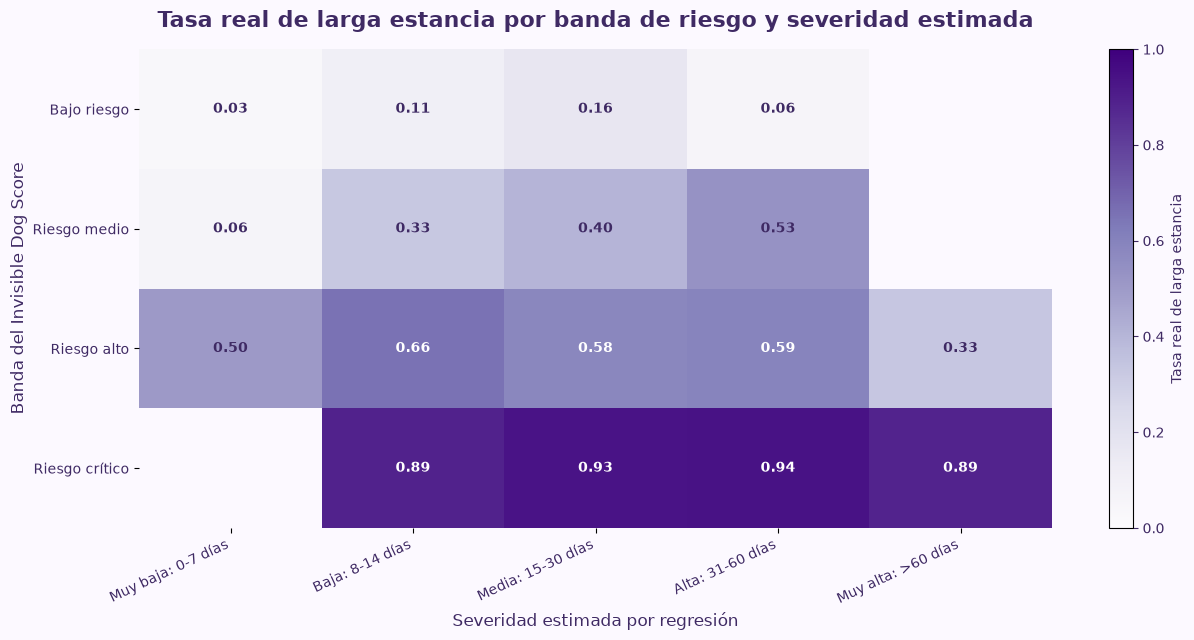

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\heatmap_riesgo_clasificacion_vs_severidad_regresion.png


In [139]:
# Mapa de calor de tasa real de larga estancia por riesgo y severidad

tabla_heatmap = (
    matriz_riesgo_severidad
    .pivot(
        index="banda_riesgo_clasificacion",
        columns="severidad_estancia_predicha",
        values="tasa_real_larga_estancia"
    )
    .reindex(index=orden_bandas_riesgo, columns=orden_severidad_predicha)
)

fig, ax = plt.subplots(figsize=(13, 6.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

valores_heatmap = tabla_heatmap.values.astype(float)

im = ax.imshow(
    valores_heatmap,
    cmap="Purples",
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_title(
    "Tasa real de larga estancia por banda de riesgo y severidad estimada",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xticks(np.arange(len(orden_severidad_predicha)))
ax.set_xticklabels(
    orden_severidad_predicha,
    rotation=25,
    ha="right",
    color="#3F2A64"
)

ax.set_yticks(np.arange(len(orden_bandas_riesgo)))
ax.set_yticklabels(
    orden_bandas_riesgo,
    color="#3F2A64"
)

ax.set_xlabel(
    "Severidad estimada por regresión",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Banda del Invisible Dog Score",
    fontsize=12,
    color="#3F2A64"
)

for i in range(valores_heatmap.shape[0]):
    for j in range(valores_heatmap.shape[1]):
        valor = valores_heatmap[i, j]
        if not np.isnan(valor):
            color_texto = "white" if valor >= 0.55 else "#3F2A64"
            ax.text(
                j,
                i,
                f"{valor:.2f}",
                ha="center",
                va="center",
                color=color_texto,
                fontsize=10,
                fontweight="bold"
            )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(
    "Tasa real de larga estancia",
    color="#3F2A64"
)
cbar.ax.yaxis.set_tick_params(color="#3F2A64")
plt.setp(cbar.ax.get_yticklabels(), color="#3F2A64")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

fig_path = figures_path / "heatmap_riesgo_clasificacion_vs_severidad_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [140]:
# Definición de una prioridad operativa combinada

def asignar_prioridad_combinada(fila):
    banda = fila["banda_riesgo_clasificacion"]
    severidad = fila["severidad_estancia_predicha"]
    
    if banda == "Riesgo crítico" and severidad in ["Alta: 31-60 días", "Muy alta: >60 días"]:
        return "Prioridad máxima"
    
    if banda == "Riesgo crítico":
        return "Prioridad muy alta"
    
    if banda == "Riesgo alto" and severidad in ["Media: 15-30 días", "Alta: 31-60 días", "Muy alta: >60 días"]:
        return "Prioridad alta"
    
    if banda == "Riesgo alto":
        return "Prioridad media-alta"
    
    if banda == "Riesgo medio" and severidad in ["Alta: 31-60 días", "Muy alta: >60 días"]:
        return "Prioridad media-alta"
    
    if banda == "Riesgo medio":
        return "Prioridad media"
    
    return "Seguimiento ordinario"


orden_prioridad_combinada = [
    "Seguimiento ordinario",
    "Prioridad media",
    "Prioridad media-alta",
    "Prioridad alta",
    "Prioridad muy alta",
    "Prioridad máxima"
]

dogs_regresion_resultados_test["prioridad_combinada"] = (
    dogs_regresion_resultados_test
    .apply(asignar_prioridad_combinada, axis=1)
)

dogs_regresion_resultados_test["prioridad_combinada"] = pd.Categorical(
    dogs_regresion_resultados_test["prioridad_combinada"],
    categories=orden_prioridad_combinada,
    ordered=True
)

resumen_prioridad_combinada = (
    dogs_regresion_resultados_test
    .groupby("prioridad_combinada", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        porcentaje_perros=("animal_id", lambda x: len(x) / len(dogs_regresion_resultados_test) * 100),
        score_medio=("invisible_dog_score", "mean"),
        dias_predichos_mediana=("stay_days_pred", "median"),
        estancia_real_mediana=("stay_days_real", "median"),
        tasa_real_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

columnas_redondear_prioridad = [
    "porcentaje_perros",
    "score_medio",
    "dias_predichos_mediana",
    "estancia_real_mediana",
    "tasa_real_larga_estancia"
]

resumen_prioridad_combinada[columnas_redondear_prioridad] = (
    resumen_prioridad_combinada[columnas_redondear_prioridad]
    .round(4)
)

print("Resumen por prioridad operativa combinada:")
display(resumen_prioridad_combinada)

Resumen por prioridad operativa combinada:


,prioridad_combinada,n_perros,porcentaje_perros,score_medio,dias_predichos_mediana,estancia_real_mediana,tasa_real_larga_estancia
0,Seguimiento ordinario,14610,77.9117,7.9657,6.3285,5.0,0.0680
1,Prioridad media,2925,15.5983,35.0853,16.4948,18.0,0.3785
2,Prioridad media-alta,122,0.6506,46.3418,32.2619,33.0,0.5656
3,Prioridad alta,755,4.0262,59.1980,29.5888,38.0,0.5841
4,Prioridad muy alta,101,0.5386,86.1743,22.6062,52.0,0.9307
5,Prioridad máxima,239,1.2745,91.0126,49.0687,58.0,0.9247


La combinación entre el Invisible Dog Score y la severidad estimada permite construir una lectura operativa más rica que cualquiera de los dos enfoques por separado.

El score de clasificación se mantiene como la señal principal para detectar perros con riesgo de larga estancia. La regresión se utiliza de forma secundaria para matizar la severidad esperada dentro de las bandas de riesgo medio, alto y crítico.

Esta decisión es importante desde el punto de vista metodológico: cuando el modelo principal asigna bajo riesgo, la predicción de días no se utiliza para elevar automáticamente la prioridad. De esta forma se evita que una señal complementaria, menos robusta que el clasificador principal, genere prioridades artificialmente altas.

Los resultados muestran que las prioridades más elevadas concentran tasas reales de larga estancia muy superiores a la media del conjunto de test. Por tanto, la prioridad combinada puede ayudar a ordenar mejor las acciones del refugio, diferenciando entre seguimiento ordinario, prioridad media, prioridad alta y prioridad máxima.

En cualquier caso, esta prioridad combinada debe interpretarse como una herramienta de apoyo operativo y no como una regla automática de decisión.

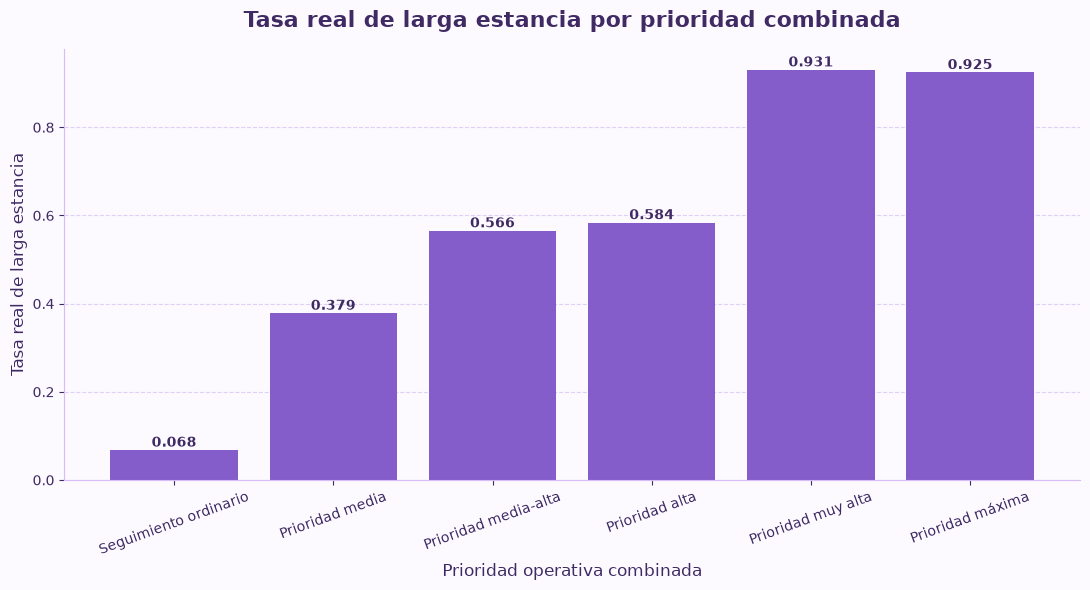

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\tasa_larga_estancia_por_prioridad_combinada.png


In [141]:
# Gráfico de tasa real de larga estancia por prioridad combinada

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    resumen_prioridad_combinada["prioridad_combinada"].astype(str),
    resumen_prioridad_combinada["tasa_real_larga_estancia"],
    color="#6F42C1",
    alpha=0.85
)

for i, valor in enumerate(resumen_prioridad_combinada["tasa_real_larga_estancia"]):
    ax.text(
        i,
        valor,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Tasa real de larga estancia por prioridad combinada",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Prioridad operativa combinada",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Tasa real de larga estancia",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64", rotation=20)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "tasa_larga_estancia_por_prioridad_combinada.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [142]:
# Guardado de resultados principales del notebook 04

resultados_regresion_comparados_path = regression_path / "comparacion_modelos_regresion_test.csv"
resumen_errores_regresion_path = regression_path / "resumen_errores_regresion_test.csv"
resumen_errores_por_tramo_path = regression_path / "errores_por_tramo_estancia_regresion_test.csv"
comparacion_clasificacion_vs_regresion_path = regression_path / "comparacion_clasificacion_vs_regresion_test.csv"
tabla_umbrales_regresion_path = regression_path / "tabla_umbrales_regresion_validacion.csv"
comparacion_topk_clasificacion_regresion_path = regression_path / "comparacion_topk_clasificacion_vs_regresion_test.csv"
resumen_severidad_predicha_path = regression_path / "resumen_severidad_estancia_predicha_test.csv"
matriz_riesgo_severidad_path = regression_path / "matriz_riesgo_clasificacion_vs_severidad_regresion_test.csv"
resumen_prioridad_combinada_path = regression_path / "resumen_prioridad_combinada_test.csv"
predicciones_regresion_test_path = regression_path / "predicciones_regresion_estancia_test.csv"

resultados_regresion_comparados.to_csv(
    resultados_regresion_comparados_path,
    index=False,
    encoding="utf-8-sig"
)

resumen_errores_regresion.to_csv(
    resumen_errores_regresion_path,
    index=False,
    encoding="utf-8-sig"
)

resumen_errores_por_tramo.to_csv(
    resumen_errores_por_tramo_path,
    index=False,
    encoding="utf-8-sig"
)

comparacion_clasificacion_vs_regresion.to_csv(
    comparacion_clasificacion_vs_regresion_path,
    index=False,
    encoding="utf-8-sig"
)

tabla_umbrales_regresion.to_csv(
    tabla_umbrales_regresion_path,
    index=False,
    encoding="utf-8-sig"
)

comparacion_topk_clasificacion_regresion.to_csv(
    comparacion_topk_clasificacion_regresion_path,
    index=False,
    encoding="utf-8-sig"
)

resumen_severidad_predicha.to_csv(
    resumen_severidad_predicha_path,
    index=False,
    encoding="utf-8-sig"
)

matriz_riesgo_severidad.to_csv(
    matriz_riesgo_severidad_path,
    index=False,
    encoding="utf-8-sig"
)

resumen_prioridad_combinada.to_csv(
    resumen_prioridad_combinada_path,
    index=False,
    encoding="utf-8-sig"
)

dogs_regresion_resultados_test.to_csv(
    predicciones_regresion_test_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados del notebook 04 guardados correctamente en:")
print(regression_path)

Resultados del notebook 04 guardados correctamente en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\regression


## 9. Interpretabilidad del modelo de regresión

Para completar el análisis complementario, se revisa la importancia de variables del mejor modelo de regresión.

El objetivo es comprobar qué factores utiliza el modelo para estimar la duración aproximada de la estancia y si estos factores son coherentes con los patrones observados en el modelo principal de clasificación.

Esta interpretación no sustituye al análisis SHAP del modelo principal, pero permite entender mejor qué variables aportan señal en la predicción de días de estancia.

In [143]:
# Importancia de variables del mejor modelo de regresión

if tipo_mejor_modelo_regresion == "catboost":
    importancia_regresion = pd.DataFrame({
        "variable": variables_catboost_regresion,
        "importancia": modelo_mejor_regresion.get_feature_importance()
    })
    
elif tipo_mejor_modelo_regresion == "lightgbm":
    modelo_lgbm_interno = modelo_mejor_regresion.named_steps["modelo"]
    preprocesador_lgbm_interno = modelo_mejor_regresion.named_steps["preprocesador"]
    
    nombres_variables_transformadas = preprocesador_lgbm_interno.get_feature_names_out()
    
    importancia_regresion_detalle = pd.DataFrame({
        "variable_transformada": nombres_variables_transformadas,
        "importancia": modelo_lgbm_interno.feature_importances_
    })
    
    def extraer_variable_original_regresion(nombre_transformado):
        nombre = nombre_transformado.replace("num__", "").replace("cat__", "")
        for variable in variables_lgbm_regresion:
            if nombre == variable or nombre.startswith(variable + "_"):
                return variable
        return nombre
    
    importancia_regresion_detalle["variable"] = (
        importancia_regresion_detalle["variable_transformada"]
        .apply(extraer_variable_original_regresion)
    )
    
    importancia_regresion = (
        importancia_regresion_detalle
        .groupby("variable", as_index=False)["importancia"]
        .sum()
    )
    
else:
    raise ValueError("Tipo de modelo de regresión no reconocido.")

importancia_regresion = (
    importancia_regresion
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

importancia_regresion["importancia_normalizada"] = (
    importancia_regresion["importancia"]
    / importancia_regresion["importancia"].sum()
)

importancia_regresion["importancia_normalizada"] = (
    importancia_regresion["importancia_normalizada"]
    .round(6)
)

print("Importancia de variables del mejor modelo de regresión:")
display(importancia_regresion.head(25))

Importancia de variables del mejor modelo de regresión:


,variable,importancia,importancia_normalizada
0,breed_intake,14.545363,0.145454
1,has_name_intake,11.777221,0.117772
2,age_months_intake,11.701212,0.117012
3,found_location,8.933541,0.089335
4,sterilized_intake,5.819432,0.058194
5,age_group_intake_type,4.936140,0.049361
6,condition_intake_type,4.266363,0.042664
7,breed_age_group,3.602601,0.036026
8,n_outcomes_dogs_last_30d,3.210878,0.032109
9,estimated_active_dogs_at_intake,3.081339,0.030813


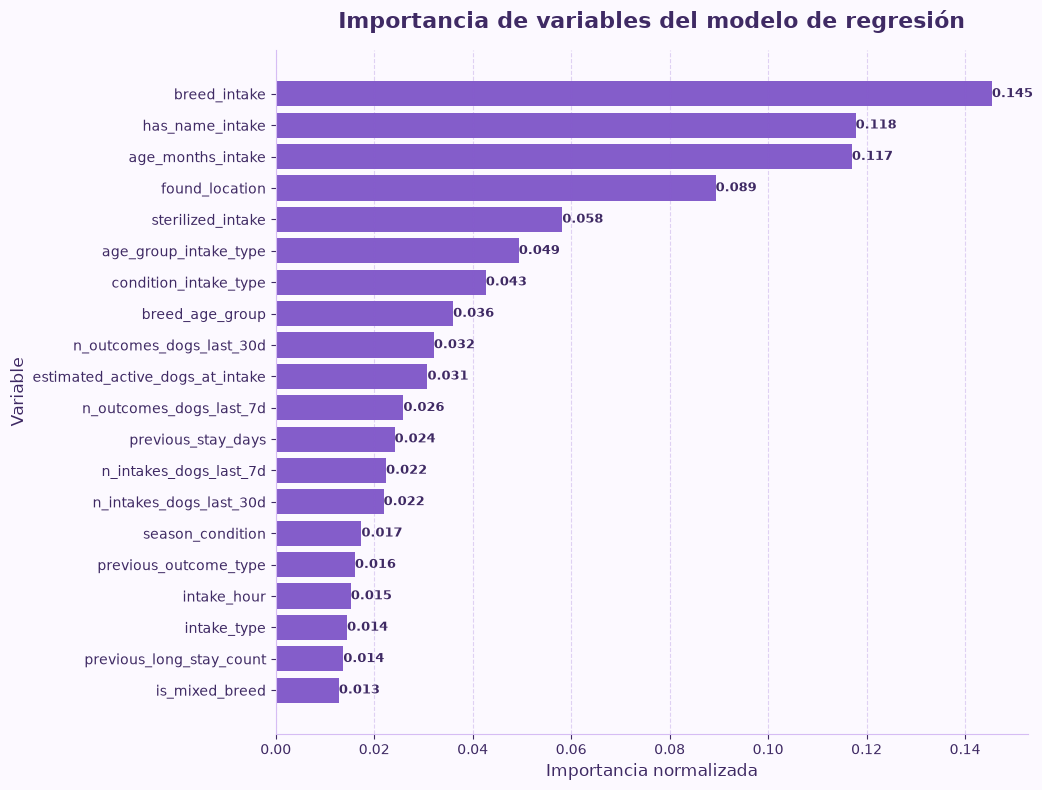

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\importancia_variables_modelo_regresion.png


In [144]:
# Gráfico de importancia de variables del modelo de regresión

top_n_importancia_regresion = 20

datos_importancia_regresion_plot = (
    importancia_regresion
    .head(top_n_importancia_regresion)
    .sort_values("importancia_normalizada", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 8))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_importancia_regresion_plot["variable"],
    datos_importancia_regresion_plot["importancia_normalizada"],
    color="#6F42C1",
    alpha=0.85
)

for i, valor in enumerate(datos_importancia_regresion_plot["importancia_normalizada"]):
    ax.text(
        valor,
        i,
        f"{valor:.3f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Importancia de variables del modelo de regresión",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel(
    "Importancia normalizada",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Variable",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "importancia_variables_modelo_regresion.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

La importancia de variables del modelo de regresión muestra que la estimación aproximada de días de estancia se apoya principalmente en características individuales del perro, información de entrada y variables de contexto.

Las variables con mayor peso son `breed_intake`, `has_name_intake`, `age_months_intake`, `found_location` y `sterilized_intake`. Esto indica que el modelo utiliza información relacionada con la raza, la identificación del animal, la edad, la procedencia y el estado de esterilización para estimar la duración esperada de la estancia.

También aparecen variables combinadas, como `age_group_intake_type`, `condition_intake_type` y `breed_age_group`, lo que sugiere que la duración esperada no depende únicamente de factores aislados, sino de combinaciones entre características individuales y condiciones de entrada.

Además, variables de contexto operativo, como `n_outcomes_dogs_last_30d`, `estimated_active_dogs_at_intake`, `n_outcomes_dogs_last_7d` y `n_intakes_dogs_last_7d`, aportan señal sobre la situación del refugio en el momento de entrada del perro. Esto es coherente con la hipótesis de que la estancia no depende solo del perfil del animal, sino también del contexto operativo en el que se produce la entrada.

En conjunto, la importancia de variables refuerza que la regresión captura patrones similares a los del modelo principal de clasificación, aunque orientados a estimar duración aproximada en lugar de detectar directamente larga estancia. Por ello, el modelo de regresión se interpreta como una herramienta complementaria de severidad, no como sustituto del Invisible Dog Score.

In [145]:
# Guardado del modelo de regresión complementario

modelo_regresion_guardado = {
    "modelo_regresion_nombre": mejor_modelo_regresion_nombre,
    "tipo_modelo_regresion": tipo_mejor_modelo_regresion,
    "modelo_regresion": modelo_mejor_regresion,
    "variable_objetivo_regresion": variable_objetivo_regresion,
    "transformacion_objetivo": "log1p",
    "variables_regresion_base": variables_regresion_base,
    "variables_catboost_regresion": variables_catboost_regresion,
    "variables_lgbm_regresion": variables_lgbm_regresion,
    "variables_categoricas_catboost_regresion": variables_categoricas_catboost_regresion,
    "resultados_regresion_comparados": resultados_regresion_comparados,
    "umbral_regresion_optimizado": umbral_regresion_optimizado,
    "tabla_umbrales_regresion": tabla_umbrales_regresion,
    "metricas_regresion_umbral_fijo_30d": metricas_regresion_como_clasificador_df,
    "metricas_regresion_umbral_optimizado": metricas_regresion_umbral_optimizado_df,
    "resumen_errores_regresion": resumen_errores_regresion,
    "resumen_errores_por_tramo": resumen_errores_por_tramo,
    "comparacion_clasificacion_vs_regresion": comparacion_clasificacion_vs_regresion,
    "comparacion_topk_clasificacion_regresion": comparacion_topk_clasificacion_regresion,
    "resumen_severidad_predicha": resumen_severidad_predicha,
    "resumen_prioridad_combinada": resumen_prioridad_combinada,
    "importancia_regresion": importancia_regresion,
    "split_test_path": str(split_test_path),
    "random_state": RANDOM_STATE
}

modelo_regresion_path = models_path / "modelo_regresion_estancia_complementario.pkl"

joblib.dump(
    modelo_regresion_guardado,
    modelo_regresion_path
)

importancia_regresion_path = regression_path / "importancia_variables_modelo_regresion.csv"

importancia_regresion.to_csv(
    importancia_regresion_path,
    index=False,
    encoding="utf-8-sig"
)

print("Modelo de regresión complementario guardado en:")
print(modelo_regresion_path)

print("\nImportancia de variables guardada en:")
print(importancia_regresion_path)

Modelo de regresión complementario guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\modelo_regresion_estancia_complementario.pkl

Importancia de variables guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\regression\importancia_variables_modelo_regresion.csv


## 10. Conclusiones del notebook

En este notebook se ha explorado una formulación complementaria del problema: la estimación aproximada de los días de estancia de cada perro en el refugio.

Los resultados muestran que la regresión aporta señal predictiva. El mejor modelo, CatBoost Regressor entrenado sobre `log1p(stay_days)`, mejora a los modelos baseline en MAE, RMSE, error absoluto mediano y correlación de Spearman. Sin embargo, el R² se mantiene bajo, lo que refleja la dificultad de estimar con precisión una variable tan asimétrica, con una elevada concentración de estancias cortas y una cola larga de valores extremos.

El análisis por tramos confirma que el modelo funciona mejor en estancias cortas y medias, pero tiende a infraestimar las estancias más largas. Esta limitación es relevante, ya que precisamente los casos de larga estancia extrema son los más difíciles de anticipar mediante una predicción continua de días.

Al convertir la regresión en una regla binaria de larga estancia, se observa que el umbral fijo de 30 días predichos genera una predicción demasiado restrictiva: identifica pocos perros como larga estancia, con una precision elevada pero un recall bajo. Para realizar una comparación más justa, se ha añadido una búsqueda de umbral sobre los días predichos en el conjunto interno de validación, utilizando el F1-score como criterio de selección.

El umbral optimizado obtenido para la regresión es de 12 días predichos. Con este ajuste, la regresión mejora de forma clara su capacidad de detección frente al umbral fijo de 30 días. No obstante, la comparación con el modelo principal confirma que la clasificación sigue siendo la formulación más adecuada para el objetivo central del proyecto, ya que mantiene mejores resultados globales en F1-score, ROC-AUC y Average Precision, y además está entrenada directamente para detectar perros con riesgo de larga estancia.

No obstante, la regresión sí aporta valor como señal complementaria. Los tramos de severidad estimada muestran una relación clara con la tasa real de larga estancia y con la mediana real de días. Por este motivo, los días predichos pueden utilizarse como una señal secundaria para matizar la prioridad operativa definida por el Invisible Dog Score.

La combinación entre el Invisible Dog Score y la severidad estimada permite construir una lectura operativa más rica. El modelo principal mantiene el papel de herramienta de detección, mientras que la regresión ayuda a diferenciar la severidad esperada dentro de los casos priorizados.

En conjunto, este análisis refuerza la decisión metodológica del proyecto: el modelo principal debe ser el clasificador interpretable de larga estancia, mientras que la regresión complementaria puede aportar información adicional sobre la duración aproximada esperada y sobre la severidad relativa de los casos priorizados.
